# Start SBI Dataset

This notebook prepares the new 512-row Battaglia y100/y102 dataset for `sbi`. It reads the combined cluster output NPZ, keeps the Sobol parameter rows, converts raw spectra to `log10(D_l)`, estimates the paired-lightcone scatter, and exposes `torch.float32` tensors ready for `inference.append_simulations(theta, x)`.


In [1]:
from matplotlib.ticker import LinearLocator, MaxNLocator
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import numpy as np

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from sbi.analysis import pairplot
    from sbi.analysis.plotting_classes import KdeOffDiagOptions
    from sbi.analysis.plotting_classes import (
        HistDiagOptions,
        HistOffDiagOptions,
        FigOptions,
        ScatterOffDiagOptions,
        ContourOffDiagOptions,
    )
    from sbi.inference import NPE
except ModuleNotFoundError:
    pairplot = None
    KdeOffDiagOptions = None
    HistDiagOptions = None
    HistOffDiagOptions = None
    FigOptions = None
    NPE = None


In [59]:
# Make the notebook work whether Jupyter is started from the repo root, SBI_analysis, emulator_tSZ, or tSZ_visuals.
import json

CWD = Path.cwd().resolve()
if CWD.name == "SBI_analysis":
    PROJECT_ROOT = CWD.parent
elif (CWD / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD
elif (CWD.parent / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

SBI_DIR = PROJECT_ROOT / "SBI_analysis"
if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, selected_ell_mask

# Default: the large emulator-generated, already-binned SBI dataset.
# This is the path produced by the 100_000-profile generation cell from the emulator notebook.
EMULATOR_SBI_DATA_PATH = (
    PROJECT_ROOT
    / "HPC_output"
    / "HalfDome"
    / "ydata_12274"
    / "sbi_battaglia_y100_12274.npz"
)

# EMULATOR_SBI_DATA_PATH = (
#     PROJECT_ROOT
#     / "emulator_tSZ"
#     / "outputs"
#     / "binned_16e3_16"
#     / "sbi16e3_bin16_dataset_100_000.npz"
# )

# If the generated dataset was saved with a different sample count/name, use the newest matching file.
# emulator_sbi_candidates = sorted(
#     (PROJECT_ROOT / "emulator_tSZ" / "outputs" / "binned_16e3_16").glob("sbi16e3_bin16_dataset_100_000.npz")
# )

emulator_sbi_candidates = sorted(
    (PROJECT_ROOT / "HPC_output" / "HalfDome" / "ydata_12274").glob("sbi_battaglia_y100_12274.npz")
)

DATA_PATH = emulator_sbi_candidates[-1] if emulator_sbi_candidates else EMULATOR_SBI_DATA_PATH

# Original generated 4096-profile, unbinned dataset. Uncomment this block to switch back later.
# DATA_PATH = (
#     PROJECT_ROOT
#     / "HPC_output"
#     / "HalfDome"
#     / "ydata_4096"
#     / "sbi_battaglia_y100_4096.npz"
# )

METADATA_PATH = DATA_PATH.with_name(DATA_PATH.stem + "_metadata.csv")
MANIFEST_PATH = DATA_PATH.with_name(DATA_PATH.stem + "_manifest.json")

OBS_Y100_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome_fiducial_nside4096_cluster.npy"
OBS_Y102_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome102_fiducial_nside4096_cluster.npy"

GAUSSIAN_BEAM_FWHM_ARCMIN = 2

ELL_MIN = 80
ELL_MAX = 7979
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

# Same 9-parameter Sobol prior used to generate the emulator-SBI dataset.
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393, 1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

print(f"DATA_PATH: {DATA_PATH}")
print(f"exists:    {DATA_PATH.exists()}")
DATA_PATH


DATA_PATH: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\HPC_output\HalfDome\ydata_12274\sbi_battaglia_y100_12274.npz
exists:    True


WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome/HPC_output/HalfDome/ydata_12274/sbi_battaglia_y100_12274.npz')

In [60]:
from sbi.analysis.plotting_classes import (
    FigOptions,
    HistDiagOptions,
    KdeDiagOptions,
    ScatterDiagOptions,
    ScatterOffDiagOptions,
    ContourOffDiagOptions,
    KdeOffDiagOptions,
    HistOffDiagOptions,
)


def _as_tensor(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu()
    return torch.as_tensor(x)


def _is_none_kind(kind):
    return kind is None or str(kind).lower() in ["none", "off", "empty", "blank"]


def _diag_options(kind, color, cmap, bins):
    kind = str(kind).lower()

    if kind == "hist":
        return HistDiagOptions(
            mpl_kwargs={
                "color": color,
                "bins": bins,
                "alpha": 0.45,
                "histtype": "stepfilled",
                "density": True,
            }
        )

    elif kind == "kde":
        return KdeDiagOptions(
            mpl_kwargs={
                "color": color,
                "alpha": 0.9,
            }
        )

    elif kind == "scatter":
        return ScatterDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 8,
                "alpha": 0.3,
            }
        )

    else:
        raise ValueError(
            f"Unsupported diagonal plot kind: {kind}. "
            "Use 'hist', 'kde', or 'scatter'."
        )


def _offdiag_options(
    kind,
    color,
    cmap,
    hidden=False,
    scatter_cmap=None,
    scatter_gradient=False,
    n_points=None,
):
    kind = str(kind).lower()

    if hidden:
        return ScatterOffDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 0,
                "alpha": 0.0,
            }
        )

    if kind == "scatter":
        if scatter_gradient:
            if n_points is None:
                raise ValueError("n_points is required for scatter_gradient=True.")

            scatter_kwargs = {
                "color": None,
                "c": np.linspace(0, 1, n_points),
                "cmap": scatter_cmap if scatter_cmap is not None else cmap,
                "s": 6,
                "alpha": 0.35,
                "rasterized": True,
            }
        else:
            scatter_kwargs = {
                "color": color,
                "s": 6,
                "alpha": 0.20,
                "rasterized": True,
            }

        return ScatterOffDiagOptions(mpl_kwargs=scatter_kwargs)

    elif kind == "contour":
        return ContourOffDiagOptions(
            mpl_kwargs={
                "colors": color,
                "alpha": 0.9,
            },
            levels=[0.68, 0.95],
        )

    elif kind == "kde":
        return KdeOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
                "alpha": 0.8,
            }
        )

    elif kind == "hist":
        return HistOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
            }
        )

    else:
        raise ValueError(
            f"Unsupported off-diagonal plot kind: {kind}. "
            "Use 'scatter', 'contour', 'kde', 'hist', or 'none'."
        )

def sbi_pairplot(
    samples,
    param_names,
    true_values=None,
    sample_labels=None,
    colors=None,
    cmaps=None,
    limits=None,
    subset=None,
    diag="hist",
    upper="contour",
    lower="scatter",
    bins=40,
    figsize=None,
    title=None,
    savepath=None,
    scatter_cmap=None,
    scatter_gradient=False,
    diag_param_labels=True,
):
    """
    Flexible pairplot wrapper for sbi posterior samples.

    Parameters
    ----------
    samples:
        Tensor/array of shape (N, ndim), or list of such arrays.
    param_names:
        List of parameter names.
    true_values:
        Optional fiducial/true parameter vector with shape (ndim,).
    sample_labels:
        Optional labels for multiple posterior sample sets.
    colors:
        Optional list of colors, one per sample set.
    cmaps:
        Optional list of colormaps, one per sample set.
    limits:
        Optional axis limits passed to sbi.analysis.pairplot.
    subset:
        Optional subset of parameters to plot, e.g. [0, 2, 4].
    diag:
        'hist', 'kde', or 'scatter'.
    upper:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    lower:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    """

    from matplotlib.ticker import LinearLocator as _LinearLocator

    # Allow one dataset or multiple datasets
    if not isinstance(samples, (list, tuple)):
        samples = [samples]

    samples = [_as_tensor(s) for s in samples]
    n_sets = len(samples)

    ndim = samples[0].shape[1]

    for s in samples:
        if s.ndim != 2:
            raise ValueError("Each sample set must have shape (N, ndim).")
        if s.shape[1] != ndim:
            raise ValueError("All sample sets must have the same number of parameters.")

    if len(param_names) != ndim:
        raise ValueError(
            f"param_names has length {len(param_names)}, but samples have ndim={ndim}."
        )

    if colors is None:
        colors = [f"C{i}" for i in range(n_sets)]

    if cmaps is None:
        default_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Greys"]
        cmaps = [default_cmaps[i % len(default_cmaps)] for i in range(n_sets)]

    if sample_labels is None:
        sample_labels = [f"samples {i}" for i in range(n_sets)]

    if len(colors) != n_sets:
        raise ValueError("colors must have one entry per sample set.")

    if len(cmaps) != n_sets:
        raise ValueError("cmaps must have one entry per sample set.")

    if len(sample_labels) != n_sets:
        raise ValueError("sample_labels must have one entry per sample set.")

    points = None
    point_labels = []
    if true_values is not None:
        points = _as_tensor(true_values)
        if points.ndim == 1:
            points = points[None, :]
        point_labels = [r"$\theta_\mathrm{true}$"]

    hide_upper = _is_none_kind(upper)
    hide_lower = _is_none_kind(lower)

    # sbi needs a valid plot type, so use invisible scatter internally.
    upper_for_pairplot = "scatter" if hide_upper else str(upper).lower()
    lower_for_pairplot = "scatter" if hide_lower else str(lower).lower()

    diag_kwargs = [
        _diag_options(diag, colors[i], cmaps[i], bins)
        for i in range(n_sets)
    ]

    upper_kwargs = [
        _offdiag_options(
            upper_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_upper,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and upper_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    lower_kwargs = [
        _offdiag_options(
            lower_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_lower,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and lower_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    if figsize is None:
        ndim_plot = len(subset) if subset is not None else ndim
        figsize = (2.4 * ndim_plot, 2.4 * ndim_plot)

    fig, axes = pairplot(
        samples,
        points=points,
        labels=param_names,
        limits=limits,
        subset=subset,
        diag=[str(diag).lower()] * n_sets,
        upper=[upper_for_pairplot] * n_sets,
        lower=[lower_for_pairplot] * n_sets,
        diag_kwargs=diag_kwargs,
        upper_kwargs=upper_kwargs,
        lower_kwargs=lower_kwargs,
        figsize=figsize,
        fig_kwargs=FigOptions(
            legend=True,
            samples_labels=sample_labels,
            samples_colors=colors,
            points_labels=point_labels,
            points_colors=["k"],
            points_offdiag={"marker": "+", "markersize": 14},
            points_diag={"marker": "+", "markersize": 14},
            title=title,
        ),
    )

    # Remove upper/lower triangle if requested
    axes_arr = np.asarray(axes)

    if axes_arr.ndim == 2:
        ndim_plot = axes_arr.shape[0]

        if hide_lower:
            for i in range(ndim_plot):
                for j in range(i):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

        if hide_upper:
            for i in range(ndim_plot):
                for j in range(i + 1, ndim_plot):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

    # Fix labels when one triangle is hidden.
    # sbi normally labels mostly outer axes, which may have been hidden.
    if diag_param_labels and axes_arr.ndim == 2:
        if subset is None:
            plotted_param_names = list(param_names)
        else:
            plotted_param_names = [param_names[i] for i in subset]

        for i, name in enumerate(plotted_param_names):
            ax = axes_arr[i, i]
            ax.set_xlabel(name)
            ax.set_title(name)

    if axes_arr.ndim == 2:
        for ax in axes_arr.ravel():
            if not ax.axison:
                continue
            ax.xaxis.set_major_locator(_LinearLocator(3))
            ax.yaxis.set_major_locator(_LinearLocator(3))
            ax.tick_params(
                axis="both",
                which="major",
                labelsize=8,
                bottom=True,
                left=True,
                labelbottom=True,
                labelleft=True,
            )
            ax.tick_params(axis="x", which="major", labelrotation=45)
            for label in ax.get_xticklabels():
                label.set_rotation(45)
                label.set_ha("right")

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, axes

These are the true parameters that will later be used in the SBI

In [61]:
true_params = [18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758,  0.731, 0.415]

Functions that will later be applied for the compton-y profiles

In [62]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    """
    Gaussian beam window function B_ell.
    """
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    B_ell = np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)

    return B_ell


def apply_gaussian_beam_to_cl(cl, fwhm_arcmin=1.6):
    """
    Apply Gaussian beam smoothing to an auto-power spectrum.
    """
    ells = np.arange(len(cl))
    B_ell = gaussian_beam_window(ells, fwhm_arcmin=fwhm_arcmin)

    cl_beamed = B_ell**2 * cl

    return cl_beamed, B_ell

## Read The SBI Dataset

The default dataset is the emulator-generated SBI NPZ. If it contains `x_log10_dl`, `x`, or `x_binned`, the notebook uses that pre-binned `log10(D_l)` datavector directly. If you switch back to the original 4096-profile raw `C_l` dataset, the same loader falls back to converting `C_l -> log10(D_l)` and the next section can bin it.


In [63]:
def npz_scalar_to_str(data, key, default=""):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    if value.shape == ():
        return str(value.item())
    if value.size == 1:
        return str(value.reshape(-1)[0])
    return default


def npz_json_dict(data, key):
    raw = npz_scalar_to_str(data, key, default="")
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}


def masked_2d_array(data, key, mask):
    values = np.asarray(data[key], dtype=float)
    if values.ndim != 2:
        raise ValueError(f"{key} must be 2D, got shape {values.shape}")
    if values.shape[1] != mask.size:
        raise ValueError(f"{key} has {values.shape[1]} ell columns, expected {mask.size}")
    return values[:, mask]


def load_generated_sbi_dataset(path, ell_min=2, ell_max=4096):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing SBI dataset: {path}\\n"
            "Generate it from emulator_tSZ/train_binned_tSZ_emulator.ipynb first, "
            "or uncomment the original 4096-profile DATA_PATH block above."
        )

    with np.load(path, allow_pickle=True) as data:
        if "theta" not in data.files or "ell" not in data.files:
            raise KeyError(f"{path} must contain at least theta and ell")
        if "theta_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["theta_columns"]).tolist()]
        elif "x_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["x_columns"]).tolist()]
        else:
            raise KeyError(f"{path} is missing theta_columns or x_columns")

        ell_all = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = selected_ell_mask(ell_all, ell_min, ell_max)
        target_kind = npz_scalar_to_str(data, "target_kind", default="")
        binning_config = npz_json_dict(data, "binning_json")

        direct_key = None
        for candidate in ("x_log10_dl", "x_binned"):
            if candidate in data.files:
                direct_key = candidate
                break
        if direct_key is None and "x" in data.files:
            x_candidate = np.asarray(data["x"])
            if x_candidate.ndim == 2 and x_candidate.shape[1] == ell_all.size:
                target_lower = target_kind.lower()
                if "log10" in target_lower or "binned" in target_lower:
                    direct_key = "x"

        x_combined = None
        x_lightcones = {}
        cl_mean = None
        cl_keys = []
        data_vector_label = ""
        if direct_key is not None:
            x_combined = masked_2d_array(data, direct_key, mask)
            data_vector_label = f"{direct_key} ({target_kind or 'log10(D_l)'})"
        else:
            cl_keys = sorted(key for key in data.files if key.startswith("cl_y"))
            spectra = {
                key: masked_2d_array(data, key, mask)
                for key in cl_keys
            }

            if spectra:
                shapes = {values.shape for values in spectra.values()}
                if len(shapes) != 1:
                    raise ValueError(f"Spectrum arrays have inconsistent shapes: {shapes}")
                if len(spectra) == 1:
                    cl_mean = next(iter(spectra.values()))
                else:
                    cl_mean = np.mean(np.stack(list(spectra.values()), axis=0), axis=0)
            elif "cl_stack" in data.files:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)
                if cl_stack.ndim != 3:
                    raise ValueError(f"Expected cl_stack with shape (n, n_lightcones, ell), got {cl_stack.shape}")
                cl_stack = cl_stack[:, :, mask]
                if cl_stack.shape[1] == 0:
                    raise ValueError(f"{path} contains an empty cl_stack")
                cl_mean = np.mean(cl_stack, axis=1)
            elif "cl_mean" in data.files:
                cl_mean = masked_2d_array(data, "cl_mean", mask)
            else:
                raise KeyError(f"{path} has no x_log10_dl/x_binned/x or C_l arrays matching cl_y*, cl_stack, or cl_mean")
            data_vector_label = "C_l converted to log10(D_l)"

        dataset = {
            "theta": np.asarray(data["theta"], dtype=float),
            "theta_columns": theta_columns,
            "ell": ell_all[mask],
            "cl_mean": cl_mean,
            "cl_keys": cl_keys,
            "x_combined": x_combined,
            "x_lightcones": x_lightcones,
            "source_path": str(path),
            "target_kind": target_kind,
            "data_vector_label": data_vector_label,
            "binning_config": binning_config,
            "is_prebinned": bool(direct_key is not None and ("binned" in target_kind.lower() or "bin_counts" in data.files or direct_key == "x_binned")),
        }

        for key in ("bin_counts", "bin_ell_min", "bin_ell_max"):
            if key in data.files:
                values = np.asarray(data[key])
                if values.ndim == 1 and values.shape[0] == ell_all.size:
                    values = values[mask]
                dataset[key] = values

        for key in cl_keys:
            dataset[key] = masked_2d_array(data, key, mask)

    n_rows = dataset["theta"].shape[0]
    data_rows = dataset["x_combined"].shape[0] if dataset["x_combined"] is not None else dataset["cl_mean"].shape[0]
    if n_rows != data_rows:
        raise ValueError("theta rows and spectrum rows do not match")
    if n_rows == 0:
        raise ValueError("Dataset contains no parameter rows")

    if n_rows <= 50_000:
        duplicate_count = n_rows - np.unique(dataset["theta"], axis=0).shape[0]
        if duplicate_count:
            raise ValueError(f"Found {duplicate_count} duplicate parameter rows in {path}")
    else:
        print(f"Skipping exact duplicate-row check for {n_rows} rows.")

    return dataset


dataset = load_generated_sbi_dataset(DATA_PATH, ell_min=ELL_MIN, ell_max=ELL_MAX)
param_names = list(dataset["theta_columns"])
prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, param_names)

if dataset["x_combined"] is not None:
    transformed = {"combined": dataset["x_combined"]}
    transformed.update(dataset.get("x_lightcones", {}))
else:
    transformed = {"combined": cl_to_log10_dl(dataset["cl_mean"], dataset["ell"])}
    for key in dataset["cl_keys"]:
        transformed[key[3:]] = cl_to_log10_dl(dataset[key], dataset["ell"])

# Keep arrays contiguous and float32 before handing them to torch.
theta_np = np.ascontiguousarray(dataset["theta"], dtype=np.float32)
x_np = np.ascontiguousarray(transformed["combined"], dtype=np.float32)
lightcone_names = [name for name in transformed if name != "combined"]
if lightcone_names:
    first_lightcone = transformed[lightcone_names[0]]
    second_lightcone = transformed[lightcone_names[1]] if len(lightcone_names) > 1 else first_lightcone
    x_y100_np = np.ascontiguousarray(transformed.get("y100", first_lightcone), dtype=np.float32)
    x_y102_np = np.ascontiguousarray(transformed.get("y102", second_lightcone), dtype=np.float32)
else:
    x_y100_np = x_np
    x_y102_np = x_np
ell_np = np.ascontiguousarray(dataset["ell"], dtype=np.float32)

if len(lightcone_names) == 1:
    combined_label = lightcone_names[0]
elif lightcone_names:
    combined_label = "mean of " + ", ".join(lightcone_names)
else:
    combined_label = dataset["data_vector_label"]

sigma_log10_dl_np = estimate_lightcone_sigma(
    x_y100_np,
    x_y102_np,
    target="single_lightcone",
    sigma_floor=1.0e-4,
    scale=1.0,
).astype(np.float32)

# Preserve the current loaded vectors. If this is the original 4096-profile dataset,
# the next section can replace these active variables with binned versions.
ell_unbinned_np = np.ascontiguousarray(ell_np, dtype=np.float32)
x_unbinned_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_unbinned_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_unbinned_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)
sigma_log10_dl_unbinned_np = np.ascontiguousarray(sigma_log10_dl_np, dtype=np.float32)

print(f"theta_np: {theta_np.shape}  parameters: {param_names}")
print(f"x_np:     {x_np.shape}  data vector: {combined_label}")
print(f"ell_np:   {ell_np.shape}  ell range: {ell_np[0]:.0f}-{ell_np[-1]:.0f}")
print(f"sigma:    {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")
print(f"pre-binned dataset: {dataset['is_prebinned']}")


theta_np: (12279, 9)  parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
x_np:     (12279, 7900)  data vector: y100
ell_np:   (7900,)  ell range: 80-7979
sigma:    (7900,)  median=0.0001
pre-binned dataset: False


In [64]:
# If full C_ell dataset

C_ell_full_bool = False
if C_ell_full_bool:
    ell_unbinned_np = ell_unbinned_np[:4095]
    x_unbinned_np = x_unbinned_np[:, :4095]
    x_y100_unbinned_np = x_y100_unbinned_np[:, :4095]
    x_y102_unbinned_np = x_y102_unbinned_np[:, :4095]
    sigma_log10_dl_unbinned_np = sigma_log10_dl_unbinned_np[:4095]
    print(f"Using full C_ell dataset with ell up to {ell_unbinned_np[-1]:.0f}")

## Datavector Binning

The emulator-generated SBI dataset is already binned, so the default below leaves it unchanged. If you switch `DATA_PATH` back to the original 4096-profile raw dataset in the config cell, uncomment the provided `DATAVECTOR_BINNING` block to bin that original dataset before SBI.


In [65]:
# Default for the emulator-generated SBI dataset: it is already binned, so do not bin again.
SO_40_BIN_EDGES = np.r_[np.arange(80, 7881, 200), 7979].astype(np.float64)

DATAVECTOR_BINNING = {
    "enabled": True,
    "mode": "custom",
    "n_bins": 40,
    "ell_min": 80,
    "ell_max": 7979,
    "custom_edges": SO_40_BIN_EDGES,
    "statistic": "mean",
    "weighting": "2ell_plus_1",
}

# To switch back to the original 4096-profile unbinned dataset, uncomment DATA_PATH
# in the config cell above and use this binning block instead:
# DATAVECTOR_BINNING = {
#     "enabled": True,
#     "mode": "log",             # "log", "linear", or "custom"
#     "n_bins": 32,
#     "ell_min": ELL_MIN,
#     "ell_max": ELL_MAX,
#     "custom_edges": None,      # e.g. [2, 10, 20, 50, 100, 200, 500, 1000, 2000, 4096]
#     "statistic": "mean",       # "mean" or "median"
#     "weighting": "uniform",    # "uniform", "ell", or "2ell_plus_1"
# }


def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting).lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values.astype(np.float64)
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def _make_bin_edges(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    ell_min = float(config.get("ell_min", np.nanmin(ell_values)))
    ell_max = float(config.get("ell_max", np.nanmax(ell_values)))
    ell_min = max(ell_min, float(np.nanmin(ell_values)))
    ell_max = min(ell_max, float(np.nanmax(ell_values)))
    if not ell_max > ell_min:
        raise ValueError(f"Need ell_max > ell_min for binning, got {ell_min} and {ell_max}")

    mode = str(config.get("mode", "log")).lower()
    if mode == "custom" or config.get("custom_edges") is not None:
        edges = np.asarray(config["custom_edges"], dtype=np.float64)
        if edges.ndim != 1 or edges.size < 2:
            raise ValueError("custom_edges must be a one-dimensional sequence with at least two values")
    else:
        n_bins = int(config.get("n_bins", 32))
        if n_bins < 1:
            raise ValueError("n_bins must be positive")
        if mode == "log":
            if ell_min <= 0:
                raise ValueError("log binning requires ell_min > 0")
            edges = np.geomspace(ell_min, ell_max, n_bins + 1)
        elif mode == "linear":
            edges = np.linspace(ell_min, ell_max, n_bins + 1)
        else:
            raise ValueError("mode must be 'log', 'linear', or 'custom'")

    edges = np.asarray(edges, dtype=np.float64)
    edges = np.unique(edges)
    if edges.size < 2:
        raise ValueError("Binning edges collapsed to fewer than two unique values")
    if np.any(np.diff(edges) <= 0):
        raise ValueError("Binning edges must be strictly increasing")
    return edges


def _split_members_to_target(members, ell_values, target_n_bins):
    members = list(members)
    target_n_bins = int(target_n_bins)
    if target_n_bins <= len(members):
        return members

    log_ell = np.log(np.maximum(np.asarray(ell_values, dtype=np.float64), 1.0))
    while len(members) < target_n_bins:
        splittable = [i for i, idx in enumerate(members) if idx.size > 1]
        if not splittable:
            break

        def bin_width(i):
            idx = members[i]
            return log_ell[idx[-1]] - log_ell[idx[0]]

        widest = max(splittable, key=bin_width)
        idx = members[widest]
        midpoint = 0.5 * (log_ell[idx[0]] + log_ell[idx[-1]])
        split_at = int(np.searchsorted(log_ell[idx], midpoint, side="right"))
        split_at = min(max(split_at, 1), idx.size - 1)
        members[widest : widest + 1] = [idx[:split_at], idx[split_at:]]

    return members


def _summarize_bin_members(members, ell_values, weighting, centers=None):
    counts = []
    bin_min = []
    bin_max = []
    computed_centers = []
    for idx in members:
        weights = _bin_weights(ell_values[idx], weighting)
        computed_centers.append(np.average(ell_values[idx], weights=weights))
        counts.append(idx.size)
        bin_min.append(ell_values[idx[0]])
        bin_max.append(ell_values[idx[-1]])
    if centers is None:
        centers = computed_centers
    return {
        "centers": np.asarray(centers, dtype=np.float32),
        "counts": np.asarray(counts, dtype=np.int64),
        "bin_min": np.asarray(bin_min, dtype=np.float32),
        "bin_max": np.asarray(bin_max, dtype=np.float32),
    }


def make_ell_binning(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = config.get("weighting", "uniform")
    if not bool(config.get("enabled", True)):
        members = [np.array([i], dtype=np.int64) for i in range(ell_values.size)]
        summary = _summarize_bin_members(members, ell_values, weighting)
        return {
            "enabled": False,
            "edges": None,
            "members": members,
            **summary,
        }

    edges = _make_bin_edges(ell_values, config)
    selected = (ell_values >= edges[0]) & (ell_values <= edges[-1])
    bin_index = np.digitize(ell_values, edges, right=False) - 1
    bin_index[ell_values == edges[-1]] = edges.size - 2

    members = []
    for i in range(edges.size - 1):
        idx = np.flatnonzero(selected & (bin_index == i))
        if idx.size:
            members.append(idx.astype(np.int64))

    if not members:
        raise ValueError("Binning produced no non-empty bins")

    mode = str(config.get("mode", "log")).lower()
    if mode != "custom" and config.get("custom_edges") is None:
        members = _split_members_to_target(members, ell_values, int(config.get("n_bins", len(members))))

    summary = _summarize_bin_members(members, ell_values, weighting)
    return {
        "enabled": True,
        "edges": edges.astype(np.float32),
        "members": members,
        **summary,
    }


def make_binning_from_bin_ranges(bin_min, bin_max, centers, weighting="uniform"):
    bin_min = np.asarray(bin_min, dtype=np.float64).reshape(-1)
    bin_max = np.asarray(bin_max, dtype=np.float64).reshape(-1)
    centers = np.asarray(centers, dtype=np.float64).reshape(-1)
    if not (bin_min.size == bin_max.size == centers.size):
        raise ValueError("bin_min, bin_max, and centers must have the same length")

    source_ell = np.arange(int(np.floor(bin_min.min())), int(np.ceil(bin_max.max())) + 1, dtype=np.float64)
    members = []
    for lo, hi, center in zip(bin_min, bin_max, centers):
        idx = np.flatnonzero((source_ell >= lo) & (source_ell <= hi))
        if idx.size == 0:
            idx = np.array([int(np.argmin(np.abs(source_ell - center)))], dtype=np.int64)
        members.append(idx.astype(np.int64))
    summary = _summarize_bin_members(members, source_ell, weighting, centers=centers)
    return source_ell.astype(np.float32), {
        "enabled": True,
        "edges": None,
        "members": members,
        **summary,
    }


def bin_last_axis(values, binning, ell_values, statistic="mean", weighting="uniform"):
    values = np.asarray(values)
    ell_values = np.asarray(ell_values, dtype=np.float64)
    if values.shape[-1] != ell_values.size:
        raise ValueError(f"Last axis has length {values.shape[-1]}, expected {ell_values.size}")

    statistic = str(statistic).lower()
    pieces = []
    for idx in binning["members"]:
        selected = values[..., idx]
        if statistic == "mean":
            weights = _bin_weights(ell_values[idx], weighting)
            pieces.append(np.average(selected, axis=-1, weights=weights))
        elif statistic == "median":
            pieces.append(np.median(selected, axis=-1))
        else:
            raise ValueError("statistic must be 'mean' or 'median'")
    return np.stack(pieces, axis=-1)


if dataset.get("is_prebinned") and DATAVECTOR_BINNING["enabled"]:
    print("Warning: DATA_PATH already appears binned; DATAVECTOR_BINNING would bin it again.")

ell_binning = make_ell_binning(ell_unbinned_np, DATAVECTOR_BINNING)
if DATAVECTOR_BINNING["enabled"]:
    x_np = np.ascontiguousarray(
        bin_last_axis(
            x_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_y100_np = np.ascontiguousarray(
        bin_last_axis(
            x_y100_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_y102_np = np.ascontiguousarray(
        bin_last_axis(
            x_y102_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    ell_np = np.ascontiguousarray(ell_binning["centers"], dtype=np.float32)
    sigma_log10_dl_np = estimate_lightcone_sigma(
        x_y100_np,
        x_y102_np,
        target="single_lightcone",
        sigma_floor=1.0e-4,
        scale=1.0,
    ).astype(np.float32)
else:
    x_np = x_unbinned_np
    x_y100_np = x_y100_unbinned_np
    x_y102_np = x_y102_unbinned_np
    ell_np = ell_unbinned_np
    sigma_log10_dl_np = sigma_log10_dl_unbinned_np

source_binning_config = dataset.get("binning_config", {}) or {}
observed_binning_statistic = source_binning_config.get("statistic", DATAVECTOR_BINNING["statistic"])
observed_binning_weighting = source_binning_config.get("weighting", DATAVECTOR_BINNING["weighting"])

if all(key in dataset for key in ("bin_ell_min", "bin_ell_max")):
    observed_bin_source_ell_np, observed_ell_binning = make_binning_from_bin_ranges(
        dataset["bin_ell_min"],
        dataset["bin_ell_max"],
        ell_np,
        weighting=observed_binning_weighting,
    )
    observed_binning_label = "dataset bin ranges"
elif DATAVECTOR_BINNING["enabled"]:
    observed_bin_source_ell_np = ell_unbinned_np
    observed_ell_binning = ell_binning
    observed_binning_label = "notebook binning"
else:
    observed_bin_source_ell_np = ell_np
    observed_ell_binning = make_ell_binning(ell_np, {**DATAVECTOR_BINNING, "enabled": False})
    observed_binning_label = "active ell grid only"

BINNING_SUMMARY = {
    "enabled": bool(DATAVECTOR_BINNING["enabled"]),
    "dataset_prebinned": bool(dataset.get("is_prebinned", False)),
    "mode": DATAVECTOR_BINNING["mode"],
    "requested_n_bins": int(DATAVECTOR_BINNING["n_bins"]),
    "n_bins": int(ell_np.size),
    "statistic": DATAVECTOR_BINNING["statistic"],
    "weighting": DATAVECTOR_BINNING["weighting"],
    "observed_binning_statistic": observed_binning_statistic,
    "observed_binning_weighting": observed_binning_weighting,
    "observed_binning_label": observed_binning_label,
    "ell_min": float(ell_np[0]),
    "ell_max": float(ell_np[-1]),
    "bin_counts": observed_ell_binning["counts"],
    "bin_ell_min": observed_ell_binning["bin_min"],
    "bin_ell_max": observed_ell_binning["bin_max"],
}

print(
    f"active datavector: {x_np.shape[1]} bins; "
    f"dataset_prebinned={BINNING_SUMMARY['dataset_prebinned']}; notebook_binning={DATAVECTOR_BINNING['enabled']}"
)
print(f"ell centers: {ell_np[0]:.1f}-{ell_np[-1]:.1f}; observed binning: {observed_binning_label}")
print(f"observed source ell: {observed_bin_source_ell_np[0]:.0f}-{observed_bin_source_ell_np[-1]:.0f}")
print(f"sigma after binning: {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")


active datavector: 40 bins; dataset_prebinned=False; notebook_binning=True
ell centers: 198.0-7929.6; observed binning: notebook binning
observed source ell: 80-7979
sigma after binning: (40,)  median=0.0001


In [66]:
PROJECT_ROOT

WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome')

In [67]:
SIMULATION_DATAVECTOR_NOISE = {
    "enabled": False,
    "mode": "planck_16bin_dl_noise_file",
    "path": str(PROJECT_ROOT / "other_sims" / "Planck" / "Dl_noise_16bin_planck_ell_21_to_1411.npy"),
    "seed": 20260612,
    "floor_dl": 1.0e-40,
}


def add_planck_dl_noise_to_log10(
    log10_dl,
    noise_sigma_dl,
    rng=None,
    floor_dl=1.0e-40,
    min_fraction_of_signal=1.0e-3,
):
    log10_dl = np.asarray(log10_dl, dtype=np.float64)
    noise_sigma_dl = np.asarray(noise_sigma_dl, dtype=np.float64).reshape(1, -1)

    rng = np.random.default_rng() if rng is None else rng

    dl = np.power(10.0, log10_dl)

    if dl.shape[-1] != noise_sigma_dl.shape[-1]:
        raise ValueError(f"x has {dl.shape[-1]} bins, Planck noise has {noise_sigma_dl.shape[-1]}")

    # Draw Planck Gaussian noise.
    delta_dl = rng.normal(
        loc=0.0,
        scale=noise_sigma_dl,
        size=dl.shape,
    )

    # Error cannot exceed Planck error, and cannot push D_l below a small
    # positive fraction of the original signal.
    positive_limit = np.minimum(noise_sigma_dl, np.abs(dl))
    negative_limit = np.minimum(noise_sigma_dl, (1.0 - min_fraction_of_signal) * np.abs(dl))

    delta_dl = np.clip(delta_dl, -negative_limit, positive_limit)

    noisy_dl = dl + delta_dl
    noisy_dl = np.maximum(noisy_dl, min_fraction_of_signal * dl)

    return np.log10(np.maximum(noisy_dl, floor_dl)).astype(np.float32)


x_clean_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_clean_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_clean_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)

if SIMULATION_DATAVECTOR_NOISE["enabled"]:
    sim_noise_rng = np.random.default_rng(int(SIMULATION_DATAVECTOR_NOISE["seed"]))

    planck_noise_sigma_dl = np.asarray(
        np.load(SIMULATION_DATAVECTOR_NOISE["path"]),
        dtype=np.float32,
    ).reshape(-1)/2

    x_np = np.ascontiguousarray(
        add_planck_dl_noise_to_log10(
            x_clean_np,
            planck_noise_sigma_dl,
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )

    x_y100_np = np.ascontiguousarray(
        add_planck_dl_noise_to_log10(
            x_y100_clean_np,
            planck_noise_sigma_dl,
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )

    x_y102_np = np.ascontiguousarray(
        add_planck_dl_noise_to_log10(
            x_y102_clean_np,
            planck_noise_sigma_dl,
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )

    simulation_noise_delta_np = np.ascontiguousarray(x_np - x_clean_np, dtype=np.float32)
else:
    planck_noise_sigma_dl = np.zeros(x_np.shape[-1], dtype=np.float32)
    simulation_noise_delta_np = np.zeros_like(x_np, dtype=np.float32)

BINNING_SUMMARY["simulation_noise"] = {
    "enabled": bool(SIMULATION_DATAVECTOR_NOISE["enabled"]),
    "mode": SIMULATION_DATAVECTOR_NOISE["mode"],
    "path": SIMULATION_DATAVECTOR_NOISE["path"],
    "seed": int(SIMULATION_DATAVECTOR_NOISE["seed"]),
    "floor_dl": float(SIMULATION_DATAVECTOR_NOISE["floor_dl"]),
}

print("simulation datavector noise enabled:", SIMULATION_DATAVECTOR_NOISE["enabled"])
print("training x clean/noisy shapes:", x_clean_np.shape, x_np.shape)
print("simulation noise delta log10(D_l):", f"rms={np.sqrt(np.mean(simulation_noise_delta_np**2)):.4g}", f"max_abs={np.max(np.abs(simulation_noise_delta_np)):.4g}")

simulation datavector noise enabled: False
training x clean/noisy shapes: (12279, 40) (12279, 40)
simulation noise delta log10(D_l): rms=0 max_abs=0


In [68]:
print("floor count:", np.sum(x_np <= np.log10(1.0e-40) + 1e-6))
print("x min/max:", np.nanmin(x_np), np.nanmax(x_np))

floor count: 0
x min/max: -17.953505 -8.880945


In [69]:
x_np

array([[-11.79464  , -11.624981 , -11.549028 , ..., -11.893837 ,
        -11.905182 , -11.9126   ],
       [-12.932487 , -12.62511  , -12.456994 , ..., -11.599099 ,
        -11.592992 , -11.587419 ],
       [-10.91757  , -10.783466 , -10.736053 , ..., -11.462234 ,
        -11.479127 , -11.490573 ],
       ...,
       [-13.518606 , -13.2577305, -13.141327 , ..., -12.81766  ,
        -12.816499 , -12.81493  ],
       [-11.910277 , -11.660562 , -11.527943 , ..., -11.450678 ,
        -11.457912 , -11.462088 ],
       [-13.360102 , -13.025461 , -12.8379755, ..., -11.919158 ,
        -11.9140625, -11.909345 ]], dtype=float32)

## Optional Gaussian Beam

This keeps both the no-beam and 1.6 arcmin Gaussian-beam versions available. The beam is applied in `log10(D_l)` space by adding `log10(B_l^2)`.


In [70]:
def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor


Gaussian_beam_bool = True
if Gaussian_beam_bool:
    x_np_gp = np.ascontiguousarray(
        apply_gaussian_beam_to_log10_dl(x_np, ell_np, fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN),
        dtype=np.float32,
    )
else:
    x_np_gp = x_np


## Sobol Parameters

`theta_np` is the Sobol sequence parameter matrix from the NPZ. Rows align one-to-one with `x_np`, `x_y100_np`, and `x_y102_np`.

In [71]:
if pd is not None:
    sobol_parameters = pd.DataFrame(theta_np, columns=param_names)
    parameter_summary = pd.DataFrame(
        {
            "parameter": param_names,
            "prior_low": prior_low_np,
            "prior_high": prior_high_np,
            "sobol_min": theta_np.min(axis=0),
            "sobol_max": theta_np.max(axis=0),
        }
    )
    display(parameter_summary)
    display(sobol_parameters.head())
else:
    sobol_parameters = theta_np
    parameter_summary = list(
        zip(param_names, prior_low_np, prior_high_np, theta_np.min(axis=0), theta_np.max(axis=0))
    )
    print("parameter, prior_low, prior_high, sobol_min, sobol_max")
    for row in parameter_summary:
        print(row)

,parameter,prior_low,prior_high,sobol_min,sobol_max
0,P0,1.832524,34.341221,1.810594,34.389332
1,xc,0.150011,0.844503,0.149102,0.844888
2,beta,3.480627,5.216611,3.480070,5.219923
3,alpha_m_P0,0.000312,0.292251,0.000035,0.292587
4,alpha_m_xc,-0.099718,0.099795,-0.099994,0.099982
5,alpha_m_beta,-0.019935,0.099767,-0.019997,0.099994
6,alpha_z_P0,-1.363457,-0.228839,-1.364329,-0.227480
7,alpha_z_xc,0.147393,1.314474,0.146231,1.315755
8,alpha_z_beta,0.083808,0.745884,0.083020,0.746995


,P0,xc,beta,alpha_m_P0,alpha_m_xc,alpha_m_beta,alpha_z_P0,alpha_z_xc,alpha_z_beta
0,15.843321,0.560989,4.014369,0.275296,-0.012267,-0.011655,-0.905254,0.551041,0.236879
1,28.375881,0.472461,4.741617,0.025437,0.007121,0.083359,-0.745501,1.165599,0.703791
2,19.011320,0.799830,3.783484,0.206677,0.063498,0.040609,-1.220071,0.767062,0.415821
3,9.169491,0.187414,4.972928,0.094074,-0.068680,0.016092,-0.457119,0.148041,0.301746
4,5.532945,0.701228,4.521941,0.140859,-0.075591,-0.001579,-1.338190,0.940401,0.532092


## Torch Tensors For `sbi`

Use `theta` and `x` directly with `sbi`. The separate y100/y102 tensors and `sigma_log10_dl` are kept in case you want to add your own noise model or condition on one lightcone.

In [72]:
if torch is None:
    theta = theta_np
    x = x_np
    x_clean = x_clean_np
    x_simulation_noise_delta = simulation_noise_delta_np
    x_gp = x_np_gp
    x_y100 = x_y100_np
    x_y102 = x_y102_np
    ell = ell_np
    sigma_log10_dl = sigma_log10_dl_np
    prior_low = prior_low_np.astype(np.float32, copy=False)
    prior_high = prior_high_np.astype(np.float32, copy=False)
    print("Torch is not installed in this kernel; using NumPy arrays for now.")
else:
    # torch.from_numpy is zero-copy on CPU; .to(...) moves only when DEVICE is cuda.
    theta_cpu = torch.from_numpy(theta_np)
    x_cpu = torch.from_numpy(x_np)
    x_clean_cpu = torch.from_numpy(x_clean_np)
    x_simulation_noise_delta_cpu = torch.from_numpy(simulation_noise_delta_np)
    x_cpu_gp = torch.from_numpy(x_np_gp)
    x_y100_cpu = torch.from_numpy(x_y100_np)
    x_y102_cpu = torch.from_numpy(x_y102_np)
    ell_cpu = torch.from_numpy(ell_np)
    sigma_log10_dl_cpu = torch.from_numpy(sigma_log10_dl_np)
    prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
    prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))

    theta = theta_cpu.to(DEVICE, non_blocking=True)
    x = x_cpu.to(DEVICE, non_blocking=True)
    x_clean = x_clean_cpu.to(DEVICE, non_blocking=True)
    x_simulation_noise_delta = x_simulation_noise_delta_cpu.to(DEVICE, non_blocking=True)
    x_gp = x_cpu_gp.to(DEVICE, non_blocking=True)
    x_y100 = x_y100_cpu.to(DEVICE, non_blocking=True)
    x_y102 = x_y102_cpu.to(DEVICE, non_blocking=True)
    ell = ell_cpu.to(DEVICE, non_blocking=True)
    sigma_log10_dl = sigma_log10_dl_cpu.to(DEVICE, non_blocking=True)
    prior_low = prior_low_cpu.to(DEVICE, non_blocking=True)
    prior_high = prior_high_cpu.to(DEVICE, non_blocking=True)

    print(theta.dtype, theta.device, theta.shape)
    print(x.dtype, x.device, x.shape)


torch.float32 cpu torch.Size([12279, 9])
torch.float32 cpu torch.Size([12279, 40])


In [73]:
# Optional: instantiate the matching sbi prior if torch and sbi are installed in this kernel.
if torch is None:
    prior = None
else:
    try:
        from sbi.utils import BoxUniform

        try:
            prior = BoxUniform(low=prior_low, high=prior_high, device=DEVICE)
        except TypeError:
            prior = BoxUniform(low=prior_low, high=prior_high)
    except ModuleNotFoundError:
        prior = None
        print("sbi is not installed in this kernel; install it before constructing BoxUniform/SNPE.")

# Your SBI code can start from here, for example:
# from sbi.inference import SNPE
# inference = SNPE(prior=prior, device=DEVICE)
# density_estimator = inference.append_simulations(theta, x).train()

prepared = {
    "theta": theta,
    "x": x,
    "x_clean": x_clean,
    "x_simulation_noise_delta": x_simulation_noise_delta,
    "x_gp": x_gp,
    "x_y100": x_y100,
    "x_y102": x_y102,
    "ell": ell,
    "sigma_log10_dl": sigma_log10_dl,
    "prior_low": prior_low,
    "prior_high": prior_high,
    "param_names": param_names,
    "prior": prior,
    "binning": BINNING_SUMMARY,
    "simulation_noise": SIMULATION_DATAVECTOR_NOISE,
    "ell_unbinned": ell_unbinned_np,
}

prepared.keys()


dict_keys(['theta', 'x', 'x_clean', 'x_simulation_noise_delta', 'x_gp', 'x_y100', 'x_y102', 'ell', 'sigma_log10_dl', 'prior_low', 'prior_high', 'param_names', 'prior', 'binning', 'simulation_noise', 'ell_unbinned'])

In [74]:
print(ell)


tensor([ 198.0181,  388.2717,  585.2470,  783.7734,  982.9012, 1182.3248,
        1381.9154, 1581.6096, 1781.3726, 1981.1835, 2181.0291, 2380.9006,
        2580.7920, 2780.6990, 2980.6187, 3180.5481, 3380.4861, 3580.4312,
        3780.3818, 3980.3374, 4180.2974, 4380.2612, 4580.2280, 4780.1973,
        4980.1694, 5180.1436, 5380.1196, 5580.0972, 5780.0767, 5980.0576,
        6180.0396, 6380.0225, 6580.0063, 6779.9917, 6979.9775, 7179.9644,
        7379.9517, 7579.9399, 7779.9282, 7929.6050])


## Observed Fiducial Spectrum

The observed fiducial spectra are read on the full ell grid and converted to `log10(D_l)`. For emulator-generated binned datasets, the notebook reconstructs the same observed bins from the saved `bin_ell_min`/`bin_ell_max` metadata instead of re-binning the already-binned emulator dataset.


In [75]:
print("observed source ell:", observed_bin_source_ell_np.shape, observed_bin_source_ell_np[0], observed_bin_source_ell_np[-1])
print("active ell bins:", ell_np.shape, ell_np[0], ell_np[-1])


observed source ell: (7900,) 80.0 7979.0
active ell bins: (40,) 198.01805 7929.605


In [76]:
SYNTHETIC_OBS_DL_PATH = PROJECT_ROOT / "emulator_tSZ" / "outputs" / "binned_40" / "x_obs_log10_dl.npy"
# SYNTHETIC_OBS_DL_PATH = PROJECT_ROOT / "tSZ_visuals" / "outputs" / "so_noise_battaglia12_fiducial_local" / "halfdome_fullsky_masked_no_noise_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax7979.npy"

PLANCK_NOISE_PATH = PROJECT_ROOT / "emulator_tSZ" / "outputs" / "binned_40" / "x_obs_log10_dl.npy"


def load_synthetic_dl_ell_2_to_7979(path):
    dl = np.asarray(np.load(path), dtype=np.float64).reshape(-1)

    if dl.size <= 7979:
        raise ValueError(
            f"{path} has only {dl.size} values. "
            "Need a full D_ell array extending to at least ell=7979."
        )

    ell = np.arange(dl.size, dtype=np.float64)
    keep = (ell >= 30) & (ell <= 40)

    return ell[keep], dl[keep]

x_obs = np.load(SYNTHETIC_OBS_DL_PATH).reshape(-1)

In [77]:
x_obs_gb = apply_gaussian_beam_to_log10_dl(x_obs, ell, fwhm_arcmin=2)



In [52]:
def load_observed_spectrum_matching_bins(path, ell_active, source_ell, source_binning):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Missing observed spectrum: {path}")

    values = np.asarray(np.load(path), dtype=np.float64).reshape(-1)
    ell_active = np.asarray(ell_active, dtype=np.float64).reshape(-1)
    source_ell = np.asarray(source_ell, dtype=np.float64).reshape(-1)

    # Case 1: observed file is already binned, e.g. Planck Table 3 16 bandpowers.
    if values.size == ell_active.size:
        x_dl = np.ascontiguousarray(values, dtype=np.float32)
        x_log10 = np.ascontiguousarray(np.log10(np.maximum(x_dl, 1.0e-40)), dtype=np.float32)
        return x_dl, x_log10, None

    # Case 2: observed file is already on the source ell grid used for binning.
    if values.size == source_ell.size:
        source_dl = np.ascontiguousarray(values, dtype=np.float32)

    # Case 3: observed file is a full D_ell array indexed by integer ell.
    else:
        if not np.allclose(source_ell, np.rint(source_ell)):
            raise ValueError("source_ell must be integer-valued to index a full observed spectrum")

        ell_index = np.rint(source_ell).astype(np.int64)
        if ell_index.min() < 0 or ell_index.max() >= values.size:
            raise ValueError(
                f"{path} has length {values.size}, cannot index "
                f"ell={ell_index.min()}-{ell_index.max()}"
            )

        source_dl = np.ascontiguousarray(values[ell_index], dtype=np.float32)

    source_log10 = np.ascontiguousarray(
        np.log10(np.maximum(source_dl, 1.0e-40)),
        dtype=np.float32,
    )

    x_log10 = np.ascontiguousarray(
        bin_last_axis(
            source_log10,
            source_binning,
            source_ell,
            statistic=observed_binning_statistic,
            weighting=observed_binning_weighting,
        ),
        dtype=np.float32,
    )

    # Keep this consistent with training: training bins log10(D_ell), then uses 10**x if needed.
    x_dl = np.ascontiguousarray(np.power(10.0, x_log10), dtype=np.float32)
    return x_dl, x_log10, source_dl


def to_torch_or_numpy(values):
    values = np.ascontiguousarray(values, dtype=np.float32)
    if torch is None:
        return values
    return torch.from_numpy(values).to(DEVICE, non_blocking=True)


def load_observed_dl_noise_for_bins(path, expected_shape):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Missing observed D_l noise vector: {path}")

    noise_dl = np.asarray(np.load(path), dtype=np.float32).reshape(-1)
    expected_shape = tuple(expected_shape)
    if noise_dl.shape != expected_shape:
        raise ValueError(
            f"{path} has shape {noise_dl.shape}, expected {expected_shape}. "
            "Regenerate Dl_noise_16bin_planck_ell_21_to_1411.npy with the same 16 Planck bins."
        )
    return np.ascontiguousarray(noise_dl, dtype=np.float32)



synthetic_ell_np = np.array(range(0,7980))
synthetic_dl_np = np.load(SYNTHETIC_OBS_DL_PATH).reshape(-1)


x_observed_log10_np = np.ascontiguousarray(
    bin_last_axis(
        np.log10(np.maximum(synthetic_dl_np, 1.0e-40)),
        observed_ell_binning,
        observed_bin_source_ell_np,
        statistic=observed_binning_statistic,
        weighting=observed_binning_weighting,
    ),
    dtype=np.float32,
)

x_observed_np = np.ascontiguousarray(10.0**x_observed_log10_np, dtype=np.float32)
x_observed_unbinned_np = synthetic_dl_np

observed_noise_dl_np = np.asarray(np.load(PLANCK_NOISE_PATH), dtype=np.float32).reshape(-1)

if observed_noise_dl_np.shape != x_observed_np.shape:
    raise ValueError(
        f"Noise vector has shape {observed_noise_dl_np.shape}, "
        f"but observed/training vector has shape {x_observed_np.shape}. "
        "For the 40-bin setup, PLANCK_NOISE_PATH must point to a 40-bin noise vector."
    )

rng = np.random.default_rng(1)

x_observed_noisy_np = np.ascontiguousarray(
    x_observed_np + rng.normal(
        loc=0.0,
        scale=observed_noise_dl_np,
        size=x_observed_np.shape,
    ).astype(np.float32),
    dtype=np.float32,
)

x_observed_noisy_log10_np = np.ascontiguousarray(
    np.log10(np.maximum(x_observed_noisy_np, 1.0e-40)),
    dtype=np.float32,
)

x_observed_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(
        x_observed_log10_np,
        ell_np,
        fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN,
    ),
    dtype=np.float32,
)

x_observed_noisy_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(
        x_observed_noisy_log10_np,
        ell_np,
        fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN,
    ),
    dtype=np.float32,
)

ValueError: Last axis has length 7980, expected 7900

## Run SBI On The 512 Dataset

`USE_GAUSSIAN_BEAM_512` selects whether the no-beam or Gaussian-beam data vector is used for both training and observation.


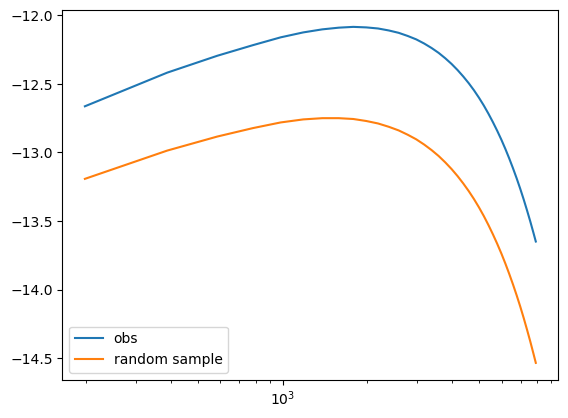

In [83]:
plt.plot(ell, x_obs_gb, label = "obs")
plt.plot(ell, prepared["x_gp"][4], label = "random sample")
plt.xscale("log")
plt.legend()

In [85]:
from sbi.inference import NLE

seed = 42
torch.manual_seed(seed)

# choose sbi method and train
inference = NPE(prior=prepared["prior"], density_estimator="zuko_maf")
density_estimator = inference.append_simulations(
    prepared["theta"],
    prepared["x_gp"],
).train(stop_after_epochs=35)

# do inference given observed data
# x_o = prepared["x_observed_noisy_log10"]
x_o = x_obs_gb
posterior = inference.build_posterior(density_estimator)
samples = posterior.sample((100000,), x=x_o)


 Neural network successfully converged after 509 epochs.

  0%|          | 0/100000 [00:00<?, ?it/s]

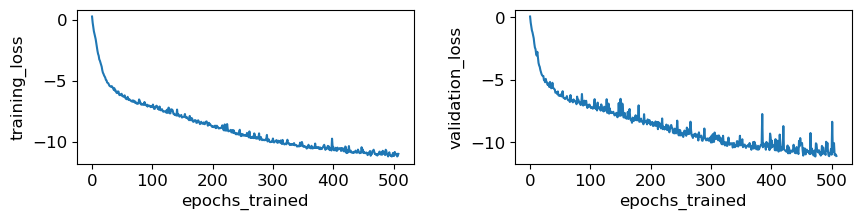

In [86]:
from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

In [80]:
samples = posterior.sample((200000,), x=x_o)


  0%|          | 0/200000 [00:00<?, ?it/s]

In [337]:
posterior_save_path = r"outputs\posteriors\posterior_16e3data_binned16_s42_xo_Planc_synthetic_NPE_zuko_maf_dataset_noise.npy"
np.save(posterior_save_path, samples)

In [18]:
prepared["param_names"]

['P0',
 'xc',
 'beta',
 'alpha_m_P0',
 'alpha_m_xc',
 'alpha_m_beta',
 'alpha_z_P0',
 'alpha_z_xc',
 'alpha_z_beta']

In [87]:
posterior_np = samples.detach().cpu().numpy()
param_names = list(prepared["param_names"])

theta_true = [18.1, 0.497, 4.35, 0.154, -0.00865,
               0.0393, -0.758,  0.731, 0.415]

true_values = np.asarray(prepared.get("theta_true", theta_true), dtype=float).reshape(-1)

summary = pd.DataFrame({
    "parameter": param_names,
    "true": true_values,
    "mean": np.mean(posterior_np, axis=0),
    "median": np.median(posterior_np, axis=0),
    "std": np.std(posterior_np, axis=0),
    "q16": np.percentile(posterior_np, 16, axis=0),
    "q84": np.percentile(posterior_np, 84, axis=0),
    "q2.5": np.percentile(posterior_np, 2.5, axis=0),
    "q97.5": np.percentile(posterior_np, 97.5, axis=0),
})
print(summary)

summary["median - true"] = summary["median"] - summary["true"]
summary["mean - true"] = summary["mean"] - summary["true"]
summary["pull"] = (summary["median"] - summary["true"]) / summary["std"]
summary["true in 68%"] = (summary["true"] >= summary["q16"]) & (summary["true"] <= summary["q84"])
summary["true in 95%"] = (summary["true"] >= summary["q2.5"]) & (summary["true"] <= summary["q97.5"])

pretty = summary.copy()
pretty["68% interval"] = pretty.apply(lambda r: f"[{r['q16']:.4g}, {r['q84']:.4g}]", axis=1)
pretty["95% interval"] = pretty.apply(lambda r: f"[{r['q2.5']:.4g}, {r['q97.5']:.4g}]", axis=1)

pretty = pretty[
    [
        "parameter",
        "true",
        "mean",
        "median",
        "std",
        "68% interval",
        "95% interval",
        "median - true",
        "pull",
        "true in 68%",
        "true in 95%",
    ]
]

display(
    pretty.style
    .format({
        "true": "{:.5g}",
        "mean": "{:.5g}",
        "median": "{:.5g}",
        "std": "{:.5g}",
        "median - true": "{:+.5g}",
        "pull": "{:+.2f}",
    })
    .background_gradient(subset=["pull"], cmap="coolwarm", vmin=-3, vmax=3)
)

      parameter      true       mean     median       std        q16  \
0            P0  18.10000  19.287331  18.715864  5.744269  13.371473   
1            xc   0.49700   0.497940   0.489223  0.115351   0.380265   
2          beta   4.35000   4.375251   4.378664  0.400703   3.944156   
3    alpha_m_P0   0.15400   0.144260   0.143941  0.067214   0.071743   
4    alpha_m_xc  -0.00865   0.001451   0.001658  0.045415  -0.047165   
5  alpha_m_beta   0.03930   0.042488   0.042940  0.027463   0.013037   
6    alpha_z_P0  -0.75800  -0.784223  -0.780595  0.260835  -1.065929   
7    alpha_z_xc   0.73100   0.738112   0.739829  0.223553   0.501049   
8  alpha_z_beta   0.41500   0.401337   0.394955  0.149217   0.243684   

         q84      q2.5      q97.5  
0  25.447640  9.708823  31.370745  
1   0.616895  0.300314   0.744839  
2   4.807379  3.608868   5.113312  
3   0.216526  0.019221   0.271455  
4   0.050275 -0.085201   0.086223  
5   0.072062 -0.010586   0.092752  
6  -0.503203 -1.281119  -0.

,parameter,true,mean,median,std,68% interval,95% interval,median - true,pull,true in 68%,true in 95%
0,P0,18.1,19.287,18.716,5.7443,"[13.37, 25.45]","[9.709, 31.37]",+0.61586,+0.11,True,True
1,xc,0.497,0.49794,0.48922,0.11535,"[0.3803, 0.6169]","[0.3003, 0.7448]",-0.007777,-0.07,True,True
2,beta,4.35,4.3753,4.3787,0.4007,"[3.944, 4.807]","[3.609, 5.113]",+0.028664,+0.07,True,True
3,alpha_m_P0,0.154,0.14426,0.14394,0.067214,"[0.07174, 0.2165]","[0.01922, 0.2715]",-0.010059,-0.15,True,True
4,alpha_m_xc,-0.00865,0.0014511,0.0016578,0.045415,"[-0.04716, 0.05027]","[-0.0852, 0.08622]",+0.010308,+0.23,True,True
5,alpha_m_beta,0.0393,0.042488,0.04294,0.027463,"[0.01304, 0.07206]","[-0.01059, 0.09275]",+0.0036402,+0.13,True,True
6,alpha_z_P0,-0.758,-0.78422,-0.78059,0.26084,"[-1.066, -0.5032]","[-1.281, -0.3041]",-0.022595,-0.09,True,True
7,alpha_z_xc,0.731,0.73811,0.73983,0.22355,"[0.501, 0.9737]","[0.3126, 1.157]",+0.0088292,+0.04,True,True
8,alpha_z_beta,0.415,0.40134,0.39495,0.14922,"[0.2437, 0.563]","[0.1346, 0.6973]",-0.020045,-0.13,True,True


In [ ]:
#### GetDist plotting
import getdist
from getdist import MCSamples, plots

In [78]:
# -----------------------------
# True / fiducial parameters
# -----------------------------
if isinstance(theta_true, torch.Tensor):
    theta_true_np = theta_true.detach().cpu().numpy()
else:
    theta_true_np = np.asarray(theta_true)

theta_true_np = theta_true_np.reshape(-1)[:n_params]

true_markers = {
    names[i]: float(theta_true_np[i])
    for i in range(n_params)
}

In [ ]:
# samples_NPE_planck = np.load("outputs\posteriors\posterior_16e3train_N5e4_binned16_s42_xo_Planck_synthetic_true_noise.npy")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kn18001\AppData\Local\Temp\ipykernel_83460\1004176485.py:1: SyntaxWarning: invalid escape sequence '\p'
  samples_NPE_planck = np.load("outputs\posteriors\posterior_16e3train_N5e4_binned16_s42_xo_Planck_synthetic_true_noise.npy")


Removed no burn in


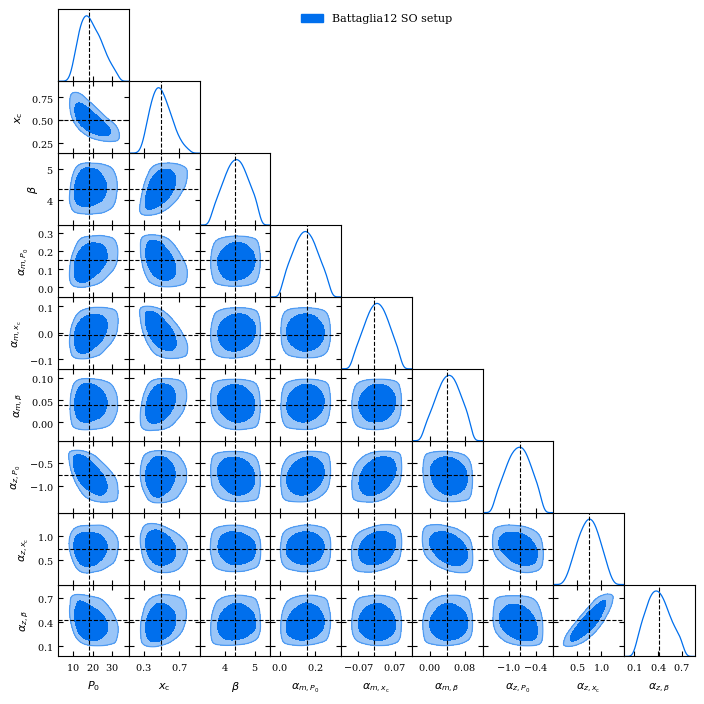

In [91]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# -----------------------------
# Helper: convert samples
# -----------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# Replace these with your two sample variables
samples_1_np = to_numpy(samples)
# samples_2_np = to_numpy(samples_NPE_planck)

# Make sure both have same number of parameters
# n_params = min(samples_1_np.shape[1],
#             #    samples_2_np.shape[1]
#                )

n_params = samples_1_np.shape[1]  # Use the number of parameters in samples_1_np

samples_1_np = samples_1_np[:, :n_params]
# samples_2_np = samples_2_np[:, :n_params]

# -----------------------------
# A&A-compatible labels
# -----------------------------
names = [f"p{i}" for i in range(n_params)]

labels = [
    r"P_0",
    r"x_{\rm c}",
    r"\beta",
    r"\alpha_{m,P_0}",
    r"\alpha_{m,x_{\rm c}}",
    r"\alpha_{m,\beta}",
    r"\alpha_{z,P_0}",
    r"\alpha_{z,x_{\rm c}}",
    r"\alpha_{z,\beta}",
][:n_params]

# -----------------------------
# GetDist samples
# -----------------------------
gd_samples_1 = MCSamples(
    samples=samples_1_np,
    names=names,
    labels=labels,
    label=r"Planck synthetic"
)

# gd_samples_2 = MCSamples(
#     samples=samples_2_np,
#     names=names,
#     labels=labels,
#     label=r"Planck true noise"
# )

for gd in [gd_samples_1,
            # gd_samples_2
            ]:
    gd.updateSettings({
        "smooth_scale_1D": 0.3,
        "smooth_scale_2D": 0.3,
        "fine_bins": 2048,
        "fine_bins_2D": 1024,
    })

# -----------------------------
# A&A figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

double_col_width_in = 18.0 / 2.54

g = plots.get_subplot_plotter(width_inch=double_col_width_in)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 8
g.settings.alpha_filled_add = 0.55
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

# -----------------------------
# Triangle plot with two samples
# -----------------------------
g.triangle_plot(
    [gd_samples_1,
    #   gd_samples_2
      ],
    params=names,
    filled=True,
    legend_labels=[
        r"Battaglia12 SO setup",
        # r"Battaglia12+Planck noise",
    ],
    contour_lws=[0.9, 0.9],
    diag1d_kwargs={"linewidth": 1.0},
    markers=true_values,
    marker_args={
        "color": "black",
        "lw": 0.8,
        "ls": "--",
    },
)

plt.savefig("SO_synthetic_obs_12k_gendata_constraints.png", dpi=300)
# plt.savefig("triangle_Planck_two_samples_AA.pdf", dpi=300)
plt.show()

## Dependence on dataset


In [112]:
from pathlib import Path
import numpy as np
import difflib

path_fid = Path("../tSZ_visuals/outputs/so_noise_battaglia12_fiducial_local").resolve()

file_fid_name = (
    "halfdome_fullsky_masked_no_noise_cl_m200c_nside4096_base_cosmo_fid_"
    "gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax7979.npy"
)

print("cwd =", Path.cwd())
print("path_fid =", path_fid)
print("path exists =", path_fid.exists())

files = [p.name for p in path_fid.iterdir()]
print("exact match =", file_fid_name in files)

target = path_fid / file_fid_name
print("target =", target)
print("target exists =", target.exists())

if not target.exists():
    print("Closest matches:")
    for m in difflib.get_close_matches(file_fid_name, files, n=10, cutoff=0.3):
        print(repr(m))

fid_yy = np.load(target)

cwd = \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis
path_fid = \\wsl.localhost\myrootfs\home\cbllover\HalfDome\tSZ_visuals\outputs\so_noise_battaglia12_fiducial_local
path exists = True
exact match = True
target = \\wsl.localhost\myrootfs\home\cbllover\HalfDome\tSZ_visuals\outputs\so_noise_battaglia12_fiducial_local\halfdome_fullsky_masked_no_noise_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax7979.npy
target exists = True


In [ ]:

ell = np.arange(0, 7980, dtype=np.float64)

cl = np.asarray(fid_yy, dtype=np.float64)
dl = cl * ell * (ell + 1.0) / (2.0 * np.pi)

SO_40_BIN_EDGES = np.r_[np.arange(80, 7881, 200), 7979].astype(np.float64)

def bin_so40(values, ell):
    values = np.asarray(values, dtype=np.float64)
    ell = np.asarray(ell, dtype=np.float64)

    binned = []
    ell_b = []

    for lo, hi in zip(SO_40_BIN_EDGES[:-1], SO_40_BIN_EDGES[1:]):
        if hi == SO_40_BIN_EDGES[-1]:
            m = (ell >= lo) & (ell <= hi)
        else:
            m = (ell >= lo) & (ell < hi)

        ell_bin = ell[m]
        val_bin = values[m]

        weights = 2.0 * ell_bin + 1.0

        binned.append(np.average(val_bin, weights=weights))
        ell_b.append(np.average(ell_bin, weights=weights))

    return np.asarray(ell_b), np.asarray(binned)

ell_b, dl_b = bin_so40(dl, ell)

x_obs_log10_dl = np.log10(np.maximum(dl_b, 1.0e-40)).astype(np.float32)

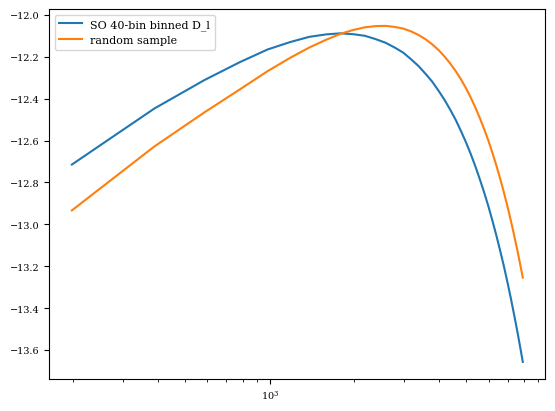

In [136]:
plt.plot(ell_b, x_obs_log10_dl - np.log10(0.4), label="SO 40-bin binned D_l")
plt.plot(ell_b, prepared["x_gp"][1], label="random sample")
plt.xscale("log")
plt.legend()

In [122]:
num_posterior_samples = 100_000
stop_after_epochs = 40
theta_true = [18.1, 0.497, 4.35, 0.154, -0.00865,
               0.0393, -0.758,  0.731, 0.415]

theta_all = prepared["theta"]
x_all = prepared["x_gp"]

# Make sure both are torch tensors
theta_all = torch.as_tensor(theta_all, dtype=torch.float32)
x_all = torch.as_tensor(x_all, dtype=torch.float32)

x_o = torch.as_tensor(
    x_obs_log10_dl,
    dtype=torch.float32,
)

# True/fiducial parameters for pull
theta_true_np = np.asarray(theta_true, dtype=float).reshape(-1)

param_names = prepared.get(
    "param_names",
    prepared.get("theta_columns", [f"theta_{i}" for i in range(theta_all.shape[1])])
)

# Dataset sizes
dataset_lengths = [1024, 2048, 4096, 8192, len(theta_all)]
dataset_lengths = [n for n in dataset_lengths if n <= len(theta_all)]
dataset_lengths = sorted(set(dataset_lengths))

print("Dataset lengths:", dataset_lengths)

Dataset lengths: [1024, 2048, 4096, 8192, 12279]


In [123]:
def get_prior_width(prior, ndim):
    """
    Tries to extract prior width from common sbi BoxUniform priors.
    If this fails, manually set prior_low and prior_high below.
    """
    if hasattr(prior, "base_dist"):
        base = prior.base_dist
        if hasattr(base, "low") and hasattr(base, "high"):
            low = base.low.detach().cpu().numpy()
            high = base.high.detach().cpu().numpy()
            return high - low

    if hasattr(prior, "low") and hasattr(prior, "high"):
        low = prior.low.detach().cpu().numpy()
        high = prior.high.detach().cpu().numpy()
        return high - low

    raise ValueError("Could not infer prior bounds. Set prior_width manually.")


prior_width = get_prior_width(prepared["prior"], theta_all.shape[1])

# If automatic prior extraction fails, use this manually:
# prior_low = np.array([...])
# prior_high = np.array([...])
# prior_width = prior_high - prior_low

In [129]:
def get_sbi_losses(inference):
    # Older sbi stores the useful arrays here.
    summary = getattr(inference, "_summary", None)

    # Fallback only if summary is actually a dict, not a method.
    if not isinstance(summary, dict):
        candidate = getattr(inference, "summary", None)
        if isinstance(candidate, dict):
            summary = candidate
        elif callable(candidate):
            try:
                candidate = candidate()
                if isinstance(candidate, dict):
                    summary = candidate
            except Exception:
                pass

    if not isinstance(summary, dict):
        print("Could not find sbi summary dict.")
        print("Available inference attrs containing 'summary':",
              [a for a in dir(inference) if "summary" in a.lower()])
        return None, None, None, None

    print("sbi summary keys:", list(summary.keys()))

    def as_array(key):
        value = summary.get(key, None)
        if value is None:
            return None
        arr = np.asarray(value, dtype=float).reshape(-1)
        return arr if arr.size else None

    train_logp = as_array("training_log_probs")
    val_logp = as_array("validation_log_probs")

    train_loss = -train_logp if train_logp is not None else None
    val_loss = -val_logp if val_logp is not None else None

    return train_logp, val_logp, train_loss, val_loss


Training NPE with n = 1024
 Neural network successfully converged after 626 epochs.

  0%|          | 0/100000 [00:00<?, ?it/s]

sbi summary keys: ['epochs_trained', 'best_validation_loss', 'validation_loss', 'training_loss', 'epoch_durations_sec']
loss history: train=None, val=None

Training NPE with n = 2048
 Neural network successfully converged after 581 epochs.

  0%|          | 0/100000 [00:00<?, ?it/s]

sbi summary keys: ['epochs_trained', 'best_validation_loss', 'validation_loss', 'training_loss', 'epoch_durations_sec']
loss history: train=None, val=None

Training NPE with n = 4096
 Neural network successfully converged after 428 epochs.

...

  0%|          | 0/100000 [00:00<?, ?it/s]

sbi summary keys: ['epochs_trained', 'best_validation_loss', 'validation_loss', 'training_loss', 'epoch_durations_sec']
loss history: train=None, val=None

Training NPE with n = 12279
 Neural network successfully converged after 606 epochs.

  0%|          | 0/100000 [00:00<?, ?it/s]

sbi summary keys: ['epochs_trained', 'best_validation_loss', 'validation_loss', 'training_loss', 'epoch_durations_sec']
loss history: train=None, val=None


,ntrain,parameter,mean,median,std,q16,q84,prior_width,std_over_prior_width,pull
0,1024,P0,16.609741,15.746972,7.269277,9.010285,24.786170,32.508698,0.223610,-0.205008
1,1024,xc,0.460409,0.450020,0.109369,0.351210,0.572448,0.694492,0.157481,-0.334565
2,1024,beta,4.399012,4.406058,0.399611,3.970183,4.832167,1.735984,0.230193,0.122650
3,1024,alpha_m_P0,0.139278,0.138068,0.068791,0.064828,0.213980,0.291939,0.235635,-0.214017
4,1024,alpha_m_xc,-0.005309,-0.005885,0.043830,-0.051867,0.041055,0.199513,0.219683,0.076231
5,1024,alpha_m_beta,0.042617,0.042889,0.027485,0.013220,0.072364,0.119702,0.229611,0.120701
6,1024,alpha_z_P0,-0.761495,-0.754337,0.264039,-1.045990,-0.476012,1.134618,0.232711,-0.013235
7,1024,alpha_z_xc,0.660337,0.650816,0.294076,0.316120,0.985205,1.167081,0.251976,-0.240287
8,1024,alpha_z_beta,0.405297,0.404395,0.187480,0.183274,0.624856,0.662076,0.283170,-0.051754
9,2048,P0,14.738358,13.939232,5.558415,9.089356,20.699595,32.508698,0.170982,-0.604784


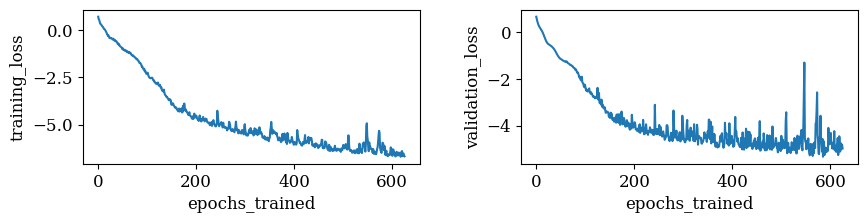

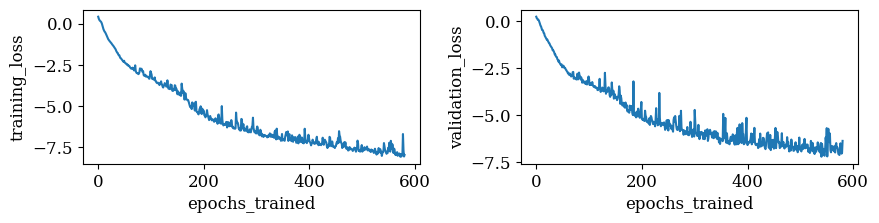

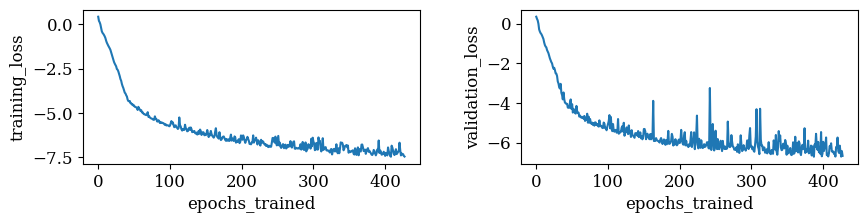

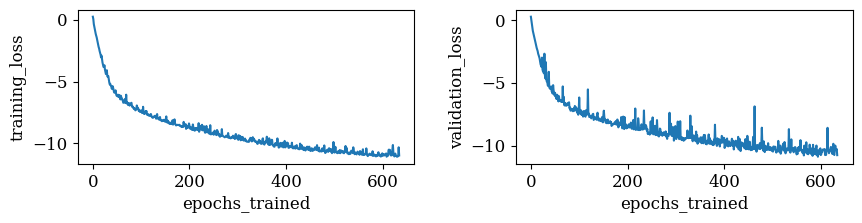

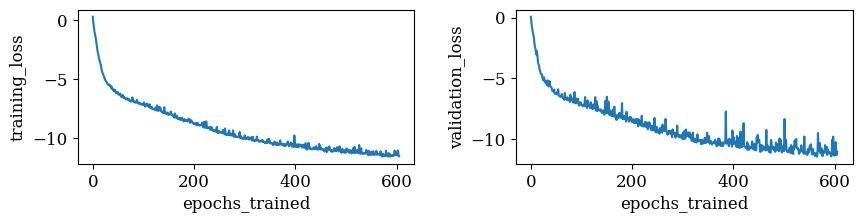

In [130]:
results = {}
summary_rows = []

for ntrain in dataset_lengths:
    print(f"\nTraining NPE with n = {ntrain}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    inference = NPE(
        prior=prepared["prior"],
        density_estimator="zuko_maf",
    )

    density_estimator = inference.append_simulations(
        theta_all[:ntrain],
        x_all[:ntrain],
    ).train(stop_after_epochs=stop_after_epochs)

    posterior = inference.build_posterior(density_estimator)

    with torch.no_grad():
        samples = posterior.sample(
            (num_posterior_samples,),
            x=x_o,
        )

    samples_np = samples.detach().cpu().numpy()

    mean = samples_np.mean(axis=0)
    std = samples_np.std(axis=0)
    median = np.median(samples_np, axis=0)
    q16 = np.percentile(samples_np, 16, axis=0)
    q84 = np.percentile(samples_np, 84, axis=0)

    width_over_prior = std / prior_width
    pull = (mean - theta_true_np) / std

    # sbi stores training summaries internally.
    # These are log-probs, so loss = -log_prob.
    train_logp = None
    val_logp = None

    train_logp, val_logp, train_loss, val_loss = get_sbi_losses(inference)

    print(
        f"loss history: "
        f"train={None if train_loss is None else train_loss.shape}, "
        f"val={None if val_loss is None else val_loss.shape}"
    )

    results[ntrain] = {
        "posterior": posterior,
        "density_estimator": density_estimator,
        "samples": samples_np,
        "mean": mean,
        "std": std,
        "median": median,
        "q16": q16,
        "q84": q84,
        "width_over_prior": width_over_prior,
        "pull": pull,
        "train_logp": train_loss,
        "val_logp": val_loss,
    }

    for j, name in enumerate(param_names):
        summary_rows.append({
            "ntrain": ntrain,
            "parameter": name,
            "mean": mean[j],
            "median": median[j],
            "std": std[j],
            "q16": q16[j],
            "q84": q84[j],
            "prior_width": prior_width[j],
            "std_over_prior_width": width_over_prior[j],
            "pull": pull[j],
        })

    _ = plot_summary(
            inference,
            tags=["training_loss", "validation_loss"],
            figsize=(10, 2),
        )

summary_df = pd.DataFrame(summary_rows)
summary_df

In [138]:
def summarize_samples(samples_np, ntrain, param_names, prior_width, theta_true_np):
    mean = samples_np.mean(axis=0)
    std = samples_np.std(axis=0)
    median = np.median(samples_np, axis=0)
    q16 = np.percentile(samples_np, 16, axis=0)
    q84 = np.percentile(samples_np, 84, axis=0)

    width_over_prior = std / prior_width
    pull = (mean - theta_true_np) / std

    rows = []
    for j, name in enumerate(param_names):
        rows.append({
            "ntrain": ntrain,
            "parameter": name,
            "mean": mean[j],
            "median": median[j],
            "std": std[j],
            "q16": q16[j],
            "q84": q84[j],
            "prior_width": prior_width[j],
            "std_over_prior_width": width_over_prior[j],
            "pull": pull[j],
        })

    stats = {
        "mean": mean,
        "std": std,
        "median": median,
        "q16": q16,
        "q84": q84,
        "width_over_prior": width_over_prior,
        "pull": pull,
    }

    return stats, rows

In [141]:
new_x_obs_np = x_obs_log10_dl - np.log10(0.4)  # shape (40,), same preprocessing as training x
new_x_obs = torch.as_tensor(new_x_obs_np, dtype=torch.float32, device=DEVICE)

In [139]:
new_results = {}
new_summary_rows = []

for ntrain, result in results.items():
    posterior = result["posterior"]

    with torch.no_grad():
        samples = posterior.sample(
            (num_posterior_samples,),
            x=new_x_obs,
        )

    samples_np = samples.detach().cpu().numpy()

    stats, rows = summarize_samples(
        samples_np,
        ntrain,
        param_names,
        prior_width,
        theta_true_np,
    )

    new_results[ntrain] = {
        "posterior": posterior,
        "density_estimator": result["density_estimator"],
        "samples": samples_np,
        **stats,
    }

    new_summary_rows.extend(rows)

new_summary_df = pd.DataFrame(new_summary_rows)
new_summary_df

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

,ntrain,parameter,mean,median,std,q16,q84,prior_width,std_over_prior_width,pull
0,1024,P0,18.395443,17.985741,6.662155,11.287982,25.643123,32.508698,0.204935,0.044346
1,1024,xc,0.519663,0.512465,0.109264,0.409211,0.632034,0.694492,0.157330,0.207418
2,1024,beta,4.398170,4.404705,0.400733,3.969236,4.832729,1.735984,0.230839,0.120204
3,1024,alpha_m_P0,0.139828,0.138828,0.068020,0.066069,0.213460,0.291939,0.232993,-0.208350
4,1024,alpha_m_xc,-0.006244,-0.006801,0.043328,-0.052239,0.039382,0.199513,0.217167,0.055527
5,1024,alpha_m_beta,0.043908,0.044316,0.027074,0.014940,0.073083,0.119702,0.226180,0.170195
6,1024,alpha_z_P0,-0.734143,-0.720271,0.267830,-1.026861,-0.443844,1.134618,0.236053,0.089074
7,1024,alpha_z_xc,0.733579,0.730723,0.281877,0.418387,1.043193,1.167081,0.241523,0.009150
8,1024,alpha_z_beta,0.418632,0.419350,0.182349,0.207070,0.629842,0.662076,0.275419,0.019920
9,2048,P0,20.160021,20.364222,6.340259,12.970518,27.021737,32.508698,0.195033,0.324911


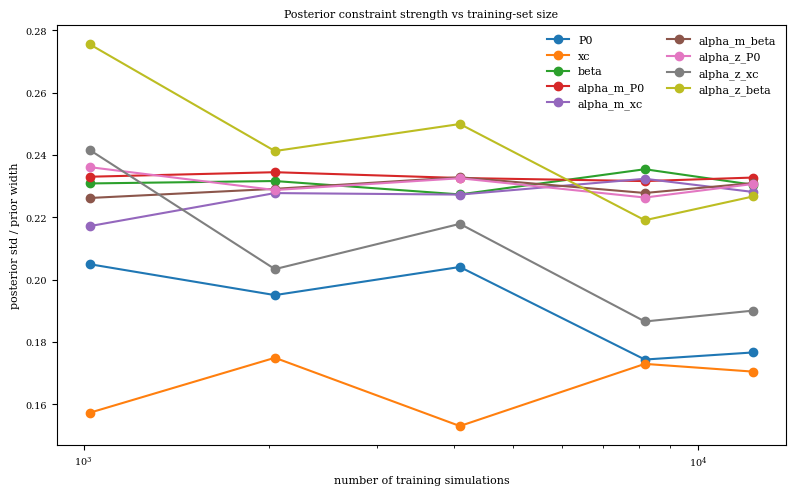

In [142]:
plt.figure(figsize=(8, 5))

for name in param_names:
    sub = new_summary_df[summary_df["parameter"] == name]
    plt.plot(
        sub["ntrain"],
        sub["std_over_prior_width"],
        marker="o",
        label=name,
    )

plt.xscale("log")
plt.xlabel("number of training simulations")
plt.ylabel(r"posterior std / prior width")
plt.title("Posterior constraint strength vs training-set size")
plt.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

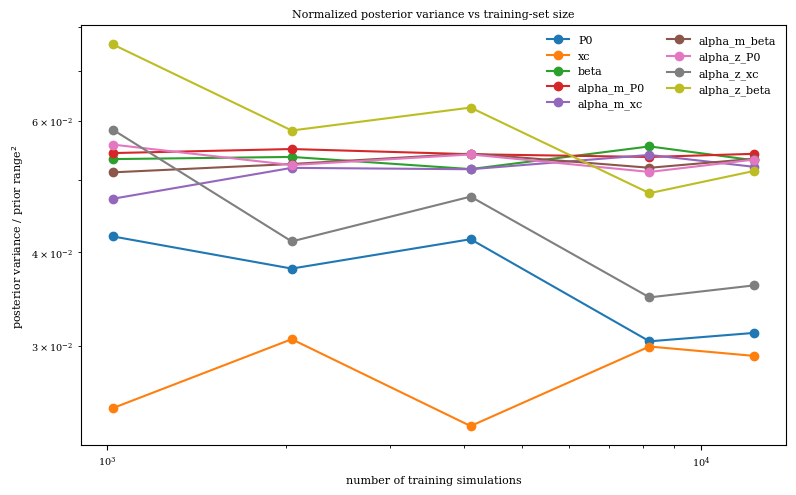

In [143]:
new_summary_df["var_over_prior_range2"] = new_summary_df["std_over_prior_width"]**2

plt.figure(figsize=(8, 5))

for name in param_names:
    sub = new_summary_df[new_summary_df["parameter"] == name]
    plt.plot(
        sub["ntrain"],
        sub["var_over_prior_range2"],
        marker="o",
        label=name,
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("number of training simulations")
plt.ylabel(r"posterior variance / prior range$^2$")
plt.title("Normalized posterior variance vs training-set size")
plt.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

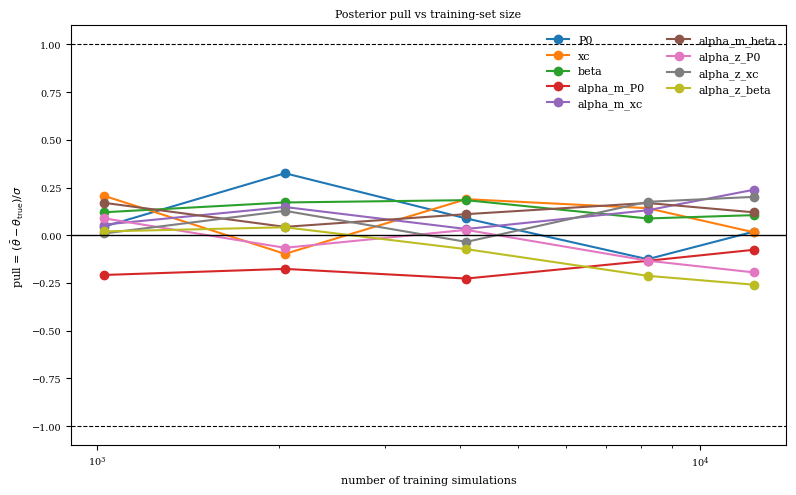

In [144]:
plt.figure(figsize=(8, 5))

for name in param_names:
    sub = new_summary_df[summary_df["parameter"] == name]
    plt.plot(
        sub["ntrain"],
        sub["pull"],
        marker="o",
        label=name,
    )

plt.axhline(0, color="black", lw=1)
plt.axhline(1, color="black", lw=0.8, ls="--")
plt.axhline(-1, color="black", lw=0.8, ls="--")

plt.xscale("log")
plt.xlabel("number of training simulations")
plt.ylabel(r"pull = $(\bar{\theta} - \theta_{\rm true}) / \sigma$")
plt.title("Posterior pull vs training-set size")
plt.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [37]:
results

{1024: {'posterior': DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>,
  'density_estimator': ZukoFlow(
    (net): Flow(
      (transform): LazyComposedTransform(
        (0): UnconditionalTransform(AffineTransform())
        (1): MaskedAutoregressiveTransform(
          (base): MonotonicAffineTransform()
          (order): [0, 1, 2, 3, 4, 5, 6, 7, 8]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=25, out_features=50, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=50, out_features=50, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=50, out_features=50, bias=True)
            (5): ReLU()
            (6): MaskedLinear(in_features=50, out_features=50, bias=True)
            (7): ReLU()
            (8): MaskedLinear(in_features=50, out_features=50, bias=True)
            (9): ReLU()
            (10): MaskedLinear(in_features=50, out_features=18, bias=True)
          )
        )
        (2)

C:\Users\kn18001\AppData\Local\Temp\ipykernel_62884\3250134163.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=8)


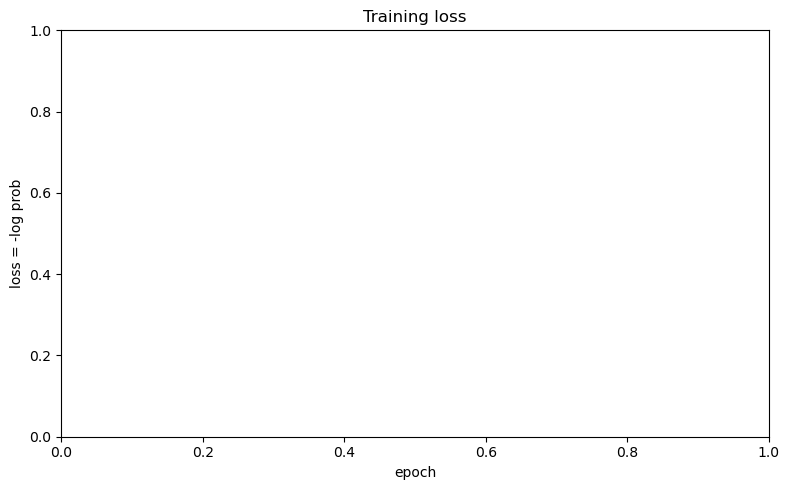

C:\Users\kn18001\AppData\Local\Temp\ipykernel_62884\3250134163.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=8)


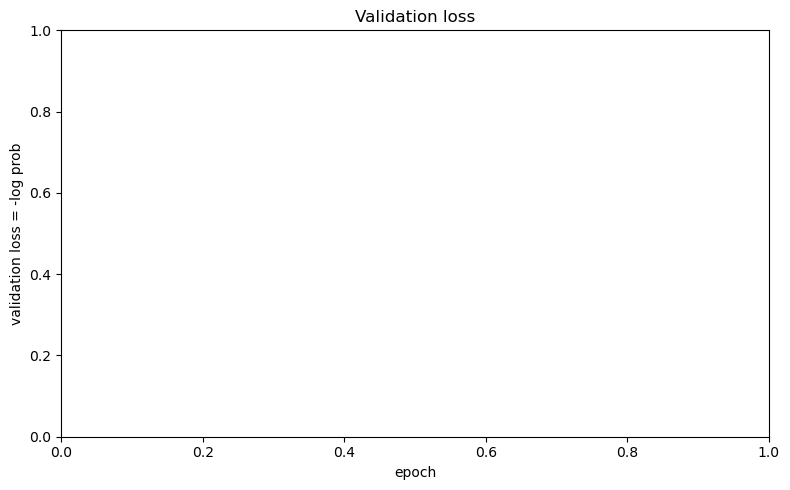

In [36]:
plt.figure(figsize=(8, 5))

for ntrain, res in results.items():
    if res["train_logp"] is not None:
        train_loss = -np.asarray(res["train_logp"], dtype=float)
        plt.plot(train_loss, label=f"train n={ntrain}")

plt.xlabel("epoch")
plt.ylabel("loss = -log prob")
plt.title("Training loss")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

for ntrain, res in results.items():
    if res["val_logp"] is not None:
        val_loss = -np.asarray(res["val_logp"], dtype=float)
        plt.plot(val_loss, label=f"val n={ntrain}")

plt.xlabel("epoch")
plt.ylabel("validation loss = -log prob")
plt.title("Validation loss")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
final_loss_rows = []

for ntrain, res in results.items():
    if res["val_logp"] is not None:
        val_loss = -np.asarray(res["val_logp"], dtype=float)
        final_loss_rows.append({
            "ntrain": ntrain,
            "final_val_loss": val_loss[-1],
            "best_val_loss": np.min(val_loss),
        })

loss_df = pd.DataFrame(final_loss_rows)

plt.figure(figsize=(7, 4))

plt.plot(loss_df["ntrain"], loss_df["final_val_loss"], marker="o", label="final val loss")
plt.plot(loss_df["ntrain"], loss_df["best_val_loss"], marker="o", label="best val loss")

plt.xscale("log")
plt.xlabel("number of training simulations")
plt.ylabel("validation loss")
plt.title("Loss vs training-set size")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

loss_df

KeyError: 'ntrain'

<Figure size 700x400 with 0 Axes>

In [28]:
theta_true

tensor([[ 1.8100e+01,  4.9700e-01,  4.3500e+00,  1.5400e-01, -8.6500e-03,
          3.9300e-02, -7.5800e-01,  7.3100e-01,  4.1500e-01]],
       dtype=torch.float64)

# Generating the "observed" function

In [103]:
samples_noisy = np.load("outputs\posteriors\posterior_100_000_emulator_sample_noisy_binned32.npy")

sample_noisy_4096 = np.load("outputs\posteriors\posterior_4096_sample_noisy_binned32.npy")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kn18001\AppData\Local\Temp\ipykernel_30940\38969436.py:1: SyntaxWarning: invalid escape sequence '\p'
  samples_noisy = np.load("outputs\posteriors\posterior_100_000_emulator_sample_noisy_binned32.npy")
C:\Users\kn18001\AppData\Local\Temp\ipykernel_30940\38969436.py:3: SyntaxWarning: invalid escape sequence '\p'
  sample_noisy_4096 = np.load("outputs\posteriors\posterior_4096_sample_noisy_binned32.npy")


In [92]:
noisy_sample.shape

(200000, 9)

In [97]:
from matplotlib.ticker import MaxNLocator
import numpy as np
import torch
import matplotlib.pyplot as plt

theta_true = torch.as_tensor(
    np.array([true_params]),
    dtype=torch.float32
).detach().cpu()

samples_clean = samples.detach().cpu()


samples_noisy = torch.as_tensor(
    samples_noisy,
    dtype=torch.float32
).detach().cpu()
# 4096 noisy samples already available as numpy
samples_4096_noisy = torch.as_tensor(
    sample_noisy_4096,
    dtype=torch.float32
).detach().cpu()

all_samples = [
    samples_clean,
    samples_noisy,
    samples_4096_noisy,
]

sample_labels = [
    "clean 1024",
    "noisy 1024",
    "noisy 4096",
]

In [98]:
combined = np.vstack([s.numpy() for s in all_samples])

limits = []
for i in range(combined.shape[1]):
    lo, hi = np.percentile(combined[:, i], [0.5, 99.5])
    pad = 0.05 * (hi - lo)
    limits.append([lo - pad, hi + pad])

In [104]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
import numpy as np
import torch
import matplotlib.pyplot as plt

def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def contour_levels_from_hist(H, probs=(0.68, 0.95)):
    Hflat = H.ravel()
    Hflat = Hflat[np.isfinite(Hflat)]
    Hsort = np.sort(Hflat)[::-1]

    cumsum = np.cumsum(Hsort)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        idx = np.searchsorted(cumsum, p)
        idx = min(idx, len(Hsort) - 1)
        levels.append(Hsort[idx])

    return sorted(levels)

def add_contours(ax, samples_np, ix, iy, limits, color, bins=60, smooth=1.0):
    x = samples_np[:, ix]
    y = samples_np[:, iy]

    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[limits[ix], limits[iy]],
        density=True
    )

    H = gaussian_filter(H, smooth)

    if not np.any(np.isfinite(H)) or np.nanmax(H) <= 0:
        return

    levels = contour_levels_from_hist(H, probs=(0.68, 0.95))

    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        H.T,
        levels=levels,
        colors=[color],
        linewidths=1.3,
        alpha=0.95,
        zorder=5
    )

In [108]:
theta_true = torch.as_tensor(
    np.array([true_params]),
    dtype=torch.float32
).detach().cpu()

samples_clean_np = to_numpy(samples)
samples_noisy_np = to_numpy(samples_noisy)
samples_4096_noisy_np = np.asarray(sample_noisy_4096)

datasets = [
    ("emulator", samples_clean_np),
    ("noisy emulator", samples_noisy_np),
    ("noisy 4096", samples_4096_noisy_np),
]

colors = {
    "emulator": "C0",
    "noisy emulator": "C1",
    "noisy 4096": "C2",
}

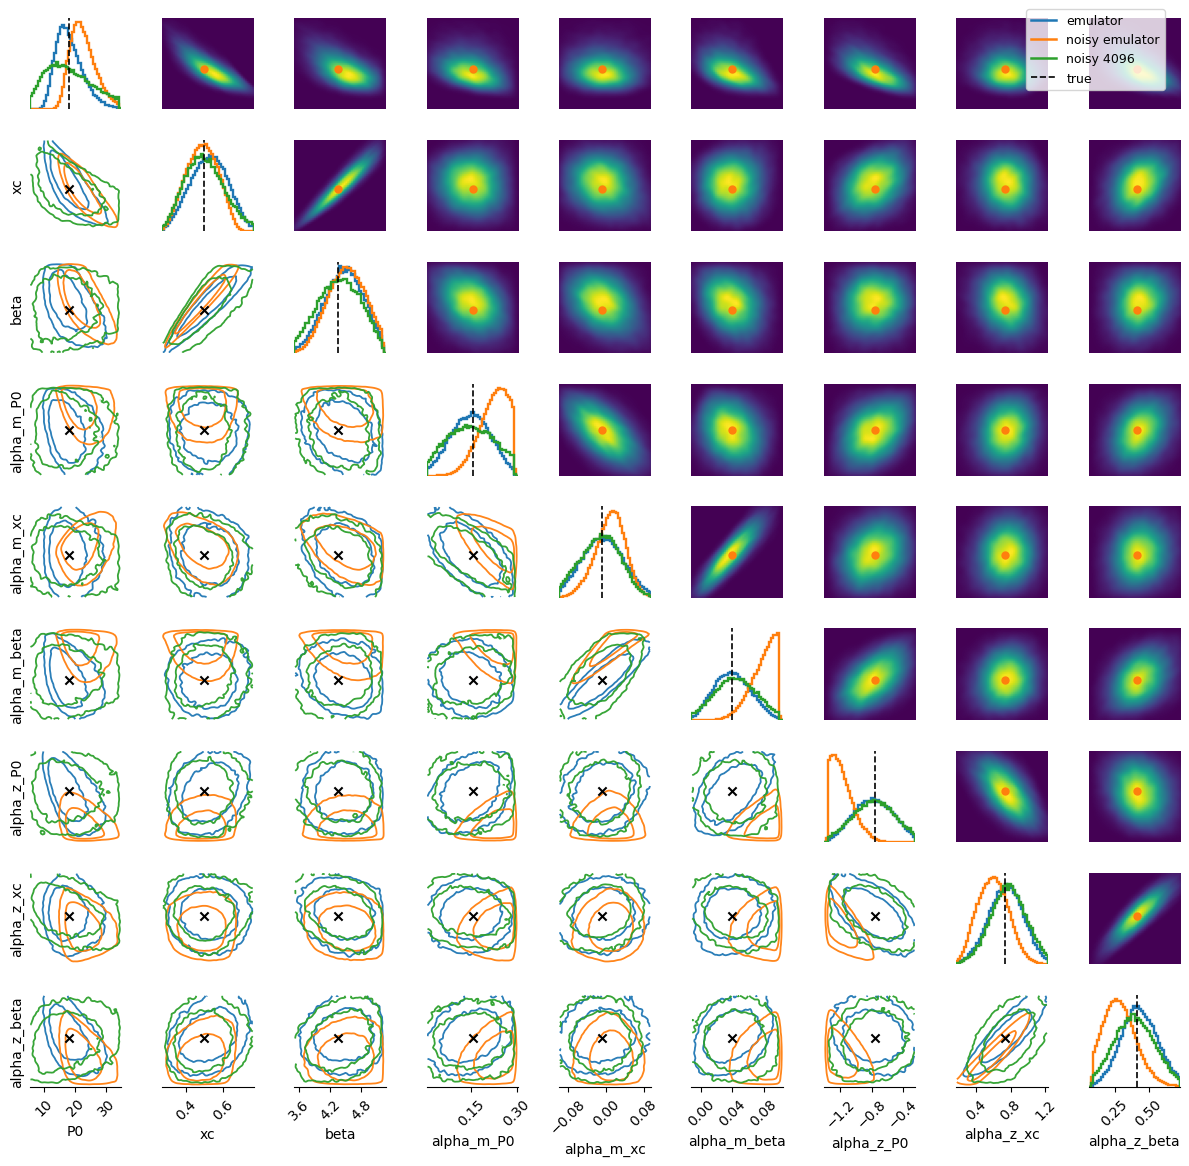

In [114]:
param_names = prepared["param_names"]
n_params = len(param_names)

fig, axes = pairplot(
    torch.as_tensor(samples_clean_np, dtype=torch.float32),
    labels=param_names,
    points=theta_true,
    limits=limits,
    figsize=(12, 12),
    upper="kde",       # only clean samples in upper triangle
    lower="contour",   # will be cleared below
    diag="hist",       # will be cleared below
)

axes = np.asarray(axes)

# Clear diagonal and lower triangle so we control them manually
for i in range(n_params):
    for j in range(n_params):
        if i >= j:
            axes[i, j].clear()

for i in range(n_params):
    ax = axes[i, i]

    for name, data in datasets:
        ax.hist(
            data[:, i],
            bins=45,
            range=limits[i],
            density=True,
            histtype="step",
            linewidth=1.7,
            color=colors[name],
            zorder=5,
        )

    # true value
    ax.axvline(
        true_params[i],
        color="k",
        linestyle="--",
        linewidth=1.2,
        zorder=6,
    )

    ax.set_xlim(limits[i])

for i in range(n_params):
    for j in range(n_params):
        if i > j:
            ax = axes[i, j]

            for name, data in datasets:
                add_contours(
                    ax,
                    data,
                    ix=j,
                    iy=i,
                    limits=limits,
                    color=colors[name],
                    bins=60,
                    smooth=1.0,
                )

            # true point
            ax.scatter(
                true_params[j],
                true_params[i],
                color="k",
                marker="x",
                s=35,
                zorder=10,
            )

            ax.set_xlim(limits[j])
            ax.set_ylim(limits[i])

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        ax.tick_params(axis="x", labelrotation=45)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

        # only outer labels
        if i == n_params - 1:
            ax.set_xlabel(param_names[j])
        else:
            ax.set_xlabel("")

        if j == 0 and i > 0:
            ax.set_ylabel(param_names[i])
        else:
            ax.set_ylabel("")

# One global legend only
legend_handles = [
    Line2D([0], [0], color=colors["emulator"], lw=1.8, label="emulator"),
    Line2D([0], [0], color=colors["noisy emulator"], lw=1.8, label="noisy emulator"),
    Line2D([0], [0], color=colors["noisy 4096"], lw=1.8, label="noisy 4096"),
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="true"),
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.savefig("pairplot_clean_kde_all_hists_all_contours.png", dpi=300)
plt.show()

In [112]:
os.getcwd()

'\\\\wsl.localhost\\myrootfs\\home\\cbllover\\HalfDome\\SBI_analysis'

In [ ]:
fig, axes = pairplot(
    datasets,
    labels=prepared["param_names"],
    points=theta_true,
    limits=limits,
    figsize=(12, 12),
    upper="kde",
    lower="contour",
    diag="hist",
    samples_labels=sample_labels,
)

axes = np.asarray(axes)
n_params = axes.shape[0]

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        ax.tick_params(axis="x", labelrotation=45)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

plt.tight_layout()
plt.savefig("pairplot_clean_noisy_4096_contours.png", dpi=300)
plt.show()